In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
general_data = pd.read_csv("datasets/general_data.csv")
general_data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,No,Travel_Rarely,Research & Development,5,4,Medical,1,4406,Female,...,3.0,Y,17,8,1,10.0,5,3,0,2
4406,29,No,Travel_Rarely,Research & Development,2,4,Medical,1,4407,Male,...,2.0,Y,15,8,0,10.0,2,3,0,2
4407,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,1,4408,Male,...,0.0,Y,20,8,0,5.0,4,4,1,2
4408,42,No,Travel_Rarely,Sales,18,2,Medical,1,4409,Male,...,0.0,Y,14,8,1,10.0,2,9,7,8


In [4]:
general_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [5]:
print(general_data['Over18'].value_counts())
print(general_data['EmployeeCount'].value_counts())
general_data['StandardHours'].value_counts()

Over18
Y    4410
Name: count, dtype: int64
EmployeeCount
1    4410
Name: count, dtype: int64


StandardHours
8    4410
Name: count, dtype: int64

Due to these variables being of the same value, we can delete due to no impact


In [6]:
general_data.drop(['Over18', 'StandardHours', 'EmployeeCount'], axis=1, inplace=True)

In [7]:
general_data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,Married,131160,1.0,11,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,Single,41890,0.0,23,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,Married,193280,1.0,15,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,Married,83210,3.0,11,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,Single,23420,4.0,12,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,No,Travel_Rarely,Research & Development,5,4,Medical,4406,Female,1,...,Single,60290,3.0,17,1,10.0,5,3,0,2
4406,29,No,Travel_Rarely,Research & Development,2,4,Medical,4407,Male,1,...,Divorced,26790,2.0,15,0,10.0,2,3,0,2
4407,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,Male,2,...,Married,37020,0.0,20,0,5.0,4,4,1,2
4408,42,No,Travel_Rarely,Sales,18,2,Medical,4409,Male,1,...,Divorced,23980,0.0,14,1,10.0,2,9,7,8


## Handling Missing values and duplicates. 

In [8]:
gdd = general_data.duplicated().any()
if gdd:
    print("There are duplicates")
else:
    print("No duplicates")

No duplicates


In [9]:
general_data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
PercentSalaryHike           0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [10]:
##numerical data fill-median, categorical data fill -mode

numerical_columns = general_data.select_dtypes(include=['float64','int64']).columns
general_data[numerical_columns] = general_data[numerical_columns].fillna(general_data[numerical_columns].median())

categorical_columns = general_data.select_dtypes(include=['object']).columns
general_data[categorical_columns] = general_data[categorical_columns].fillna(general_data[categorical_columns].mode().iloc[0])

general_data.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
PercentSalaryHike          0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

## Exploratory Data Analysis (EDA) - General data

1. Figure out distribution in each column
2. Boxplots for outliers
3. Correlation Heatmap


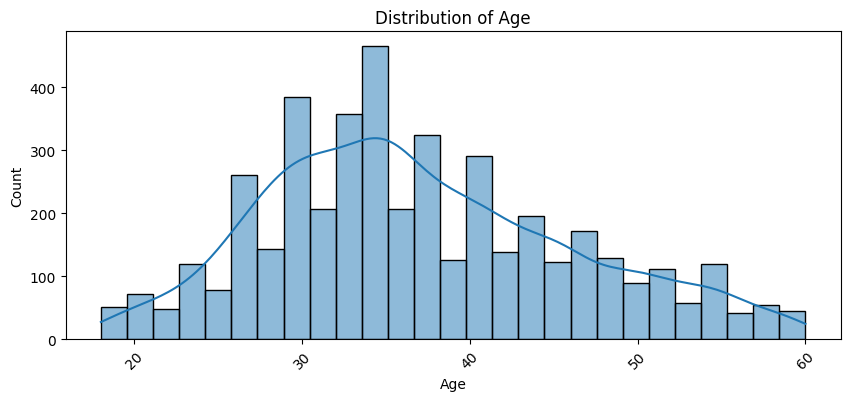

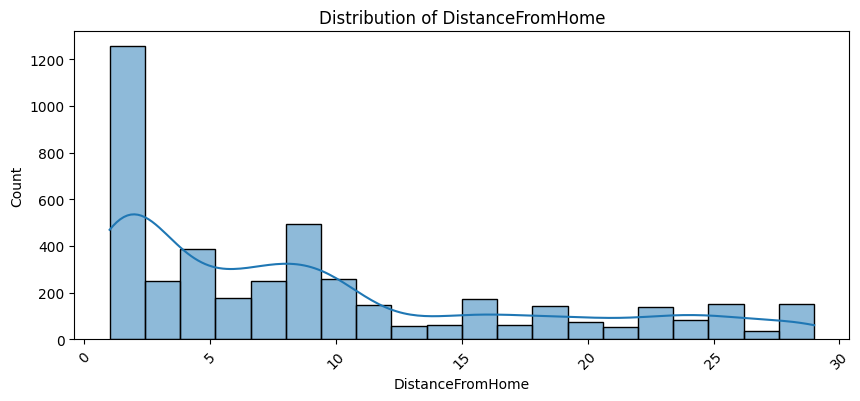

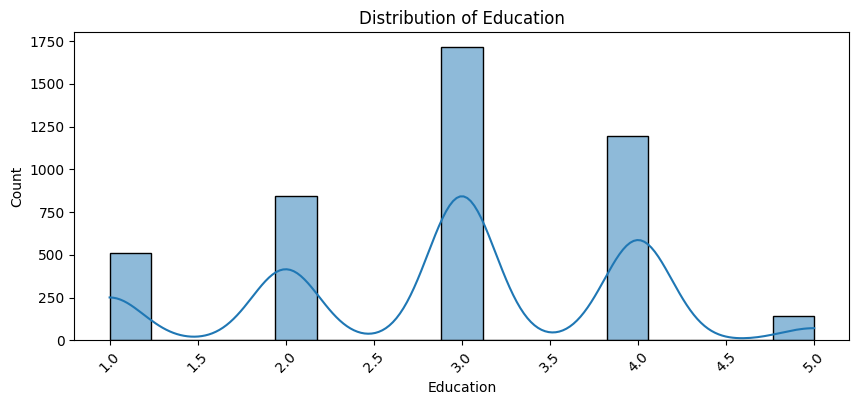

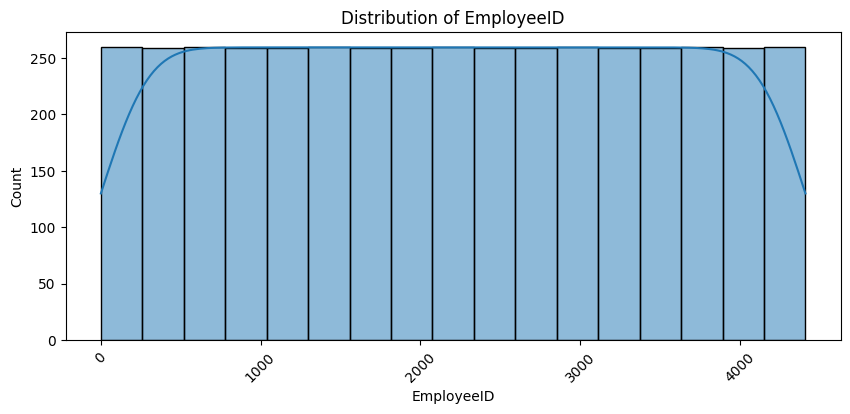

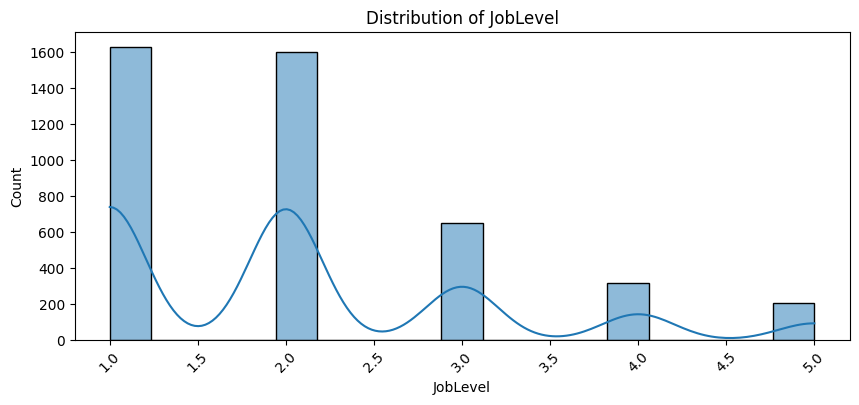

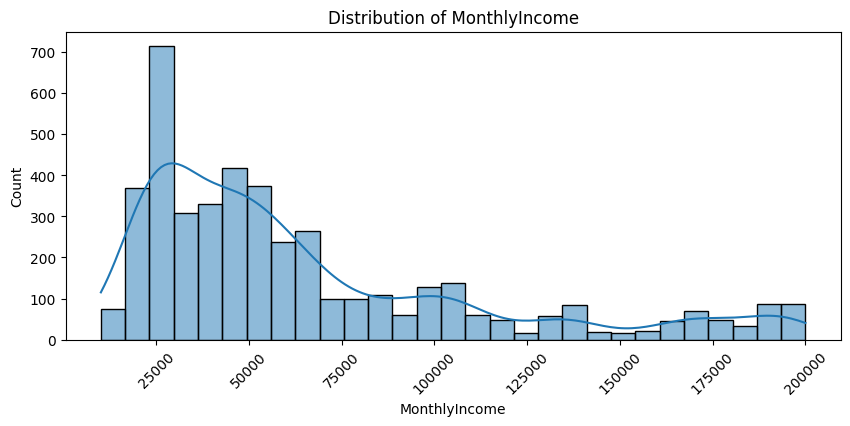

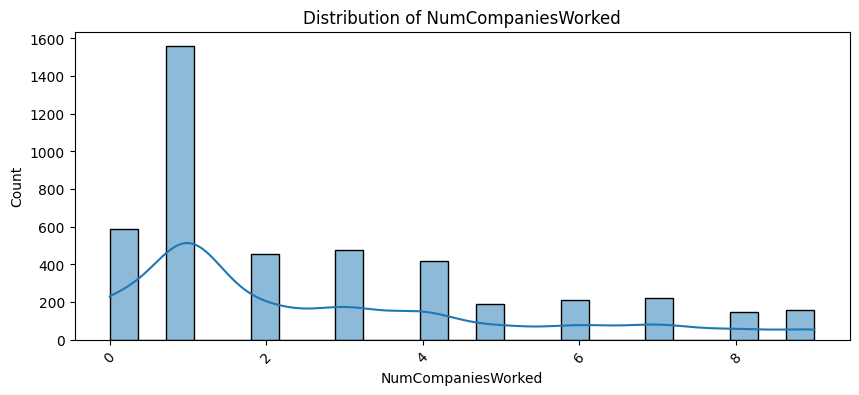

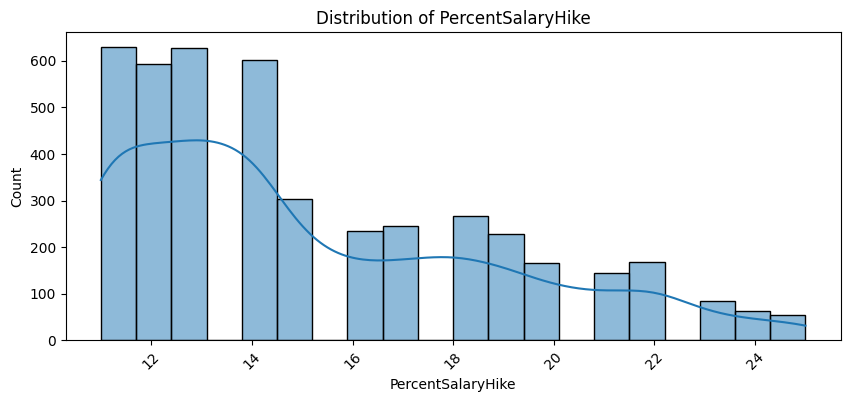

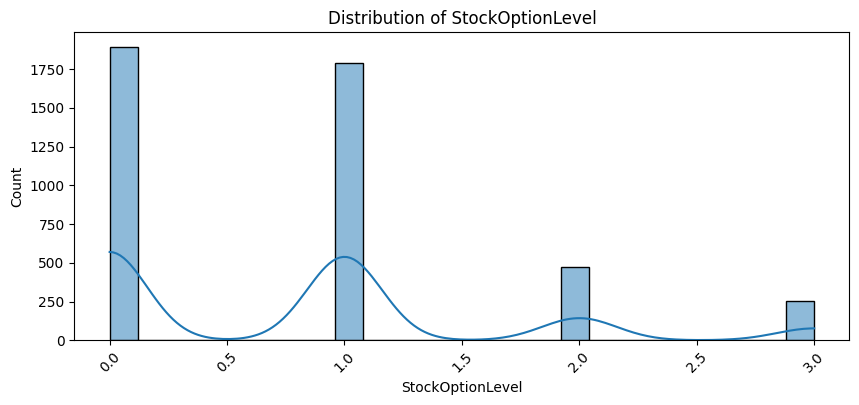

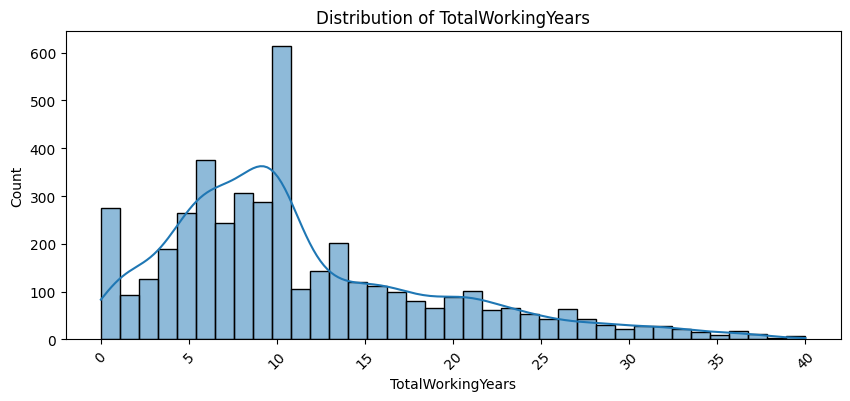

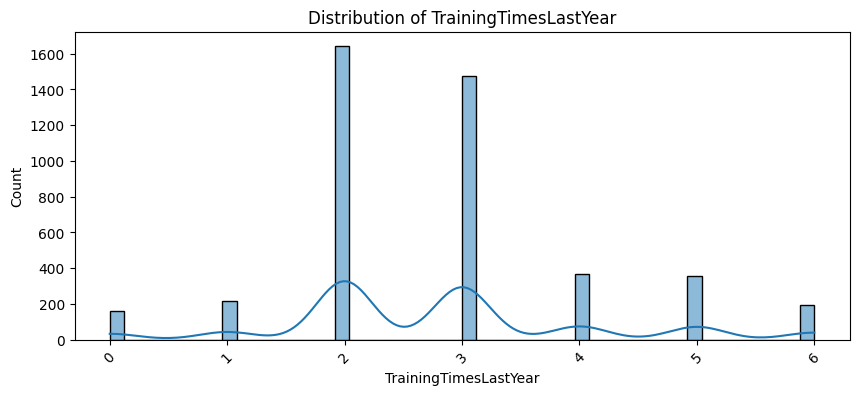

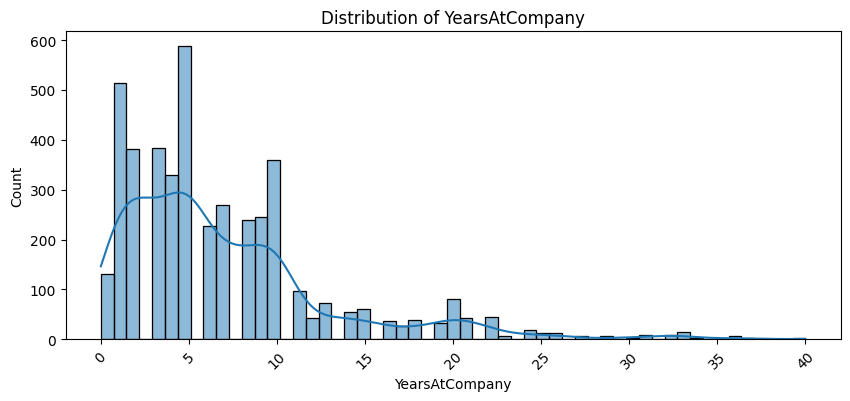

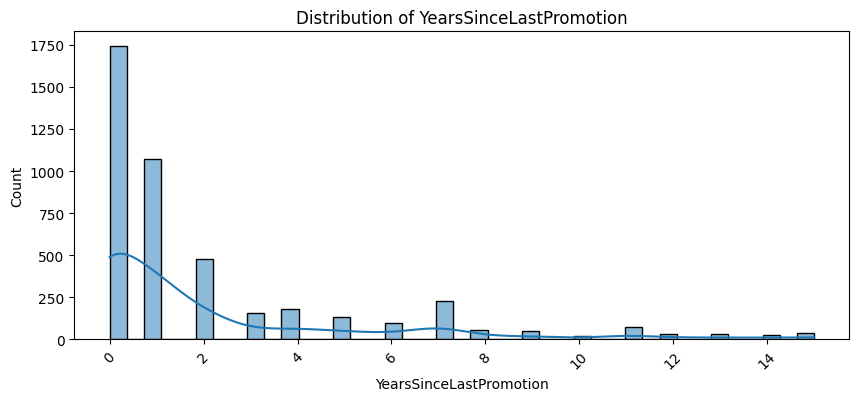

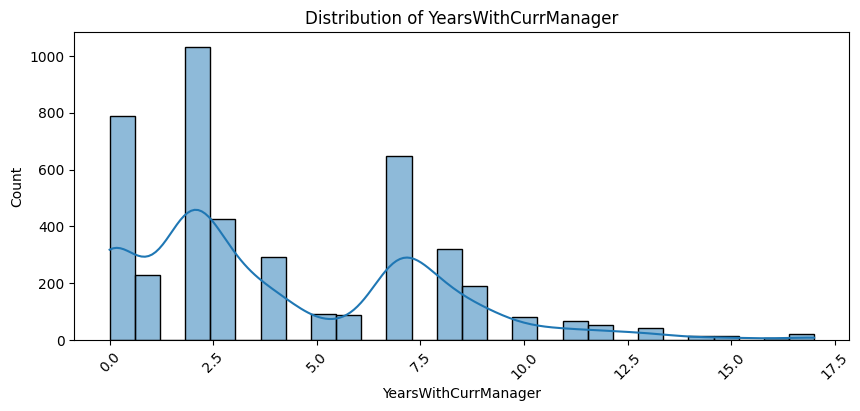

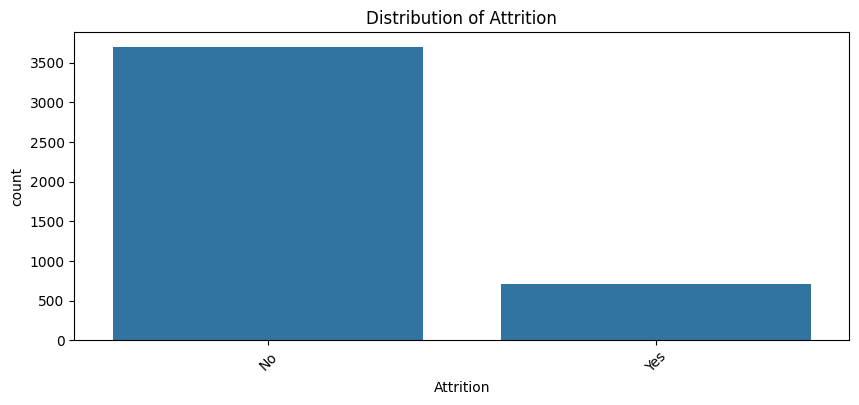

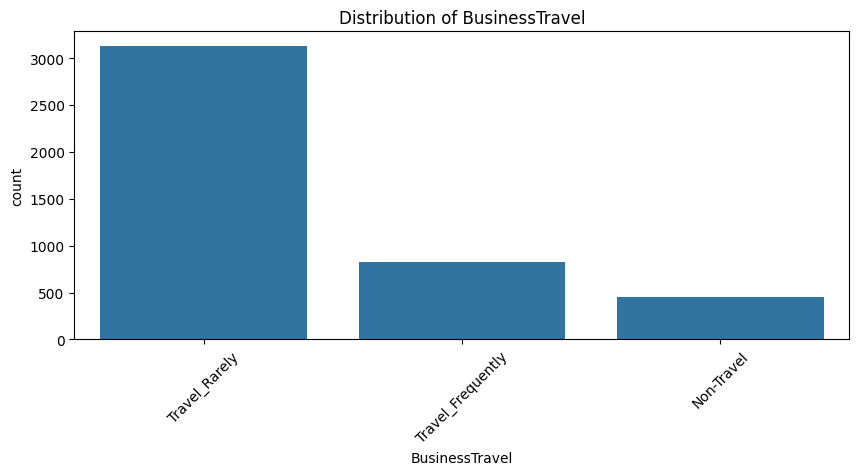

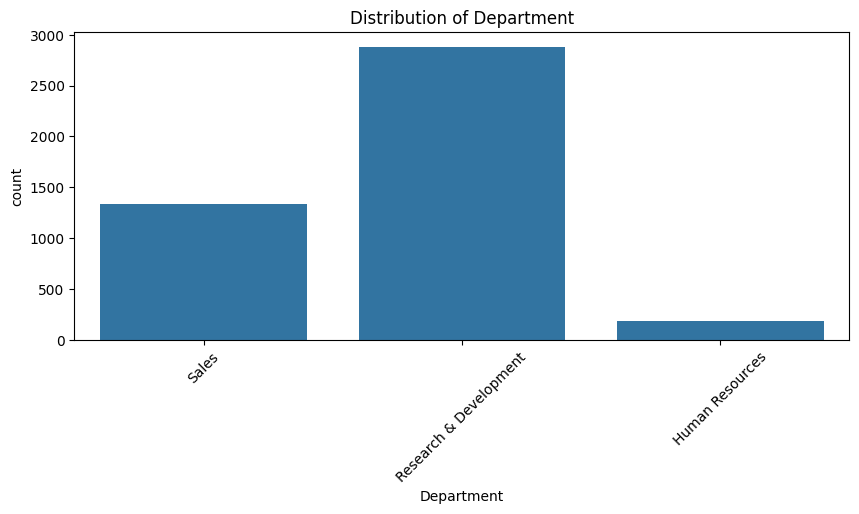

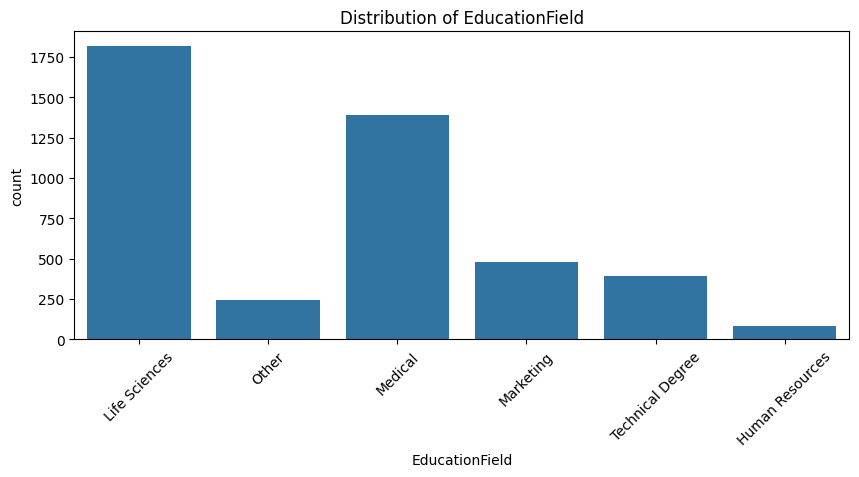

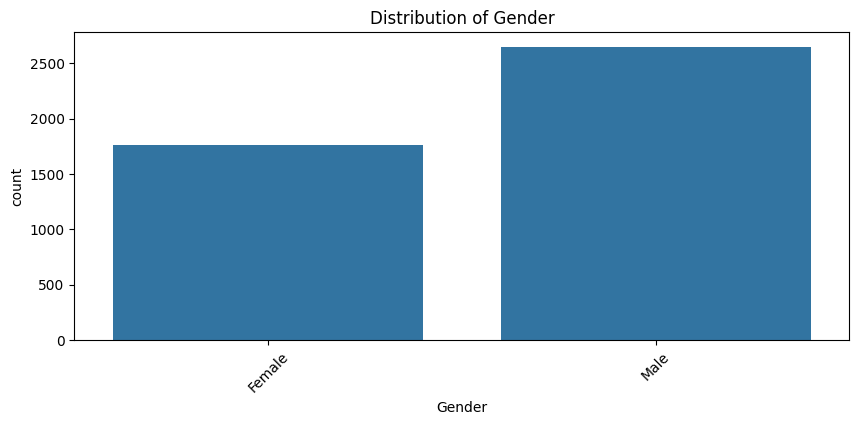

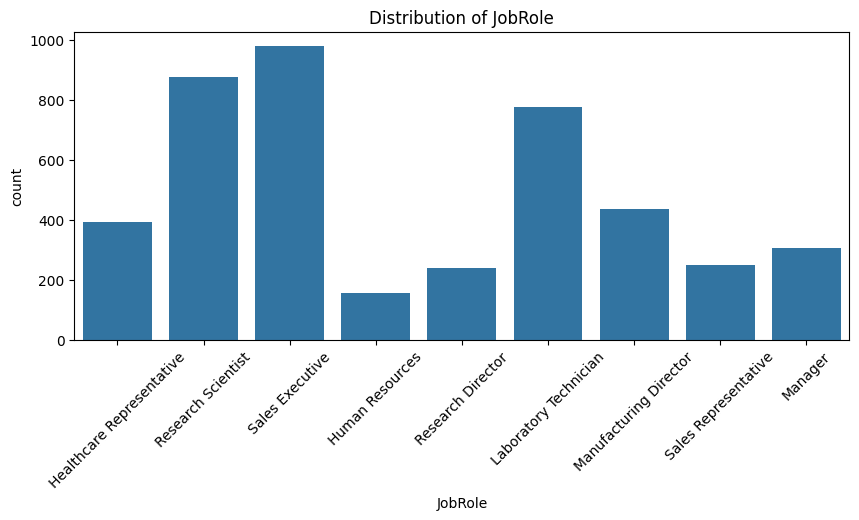

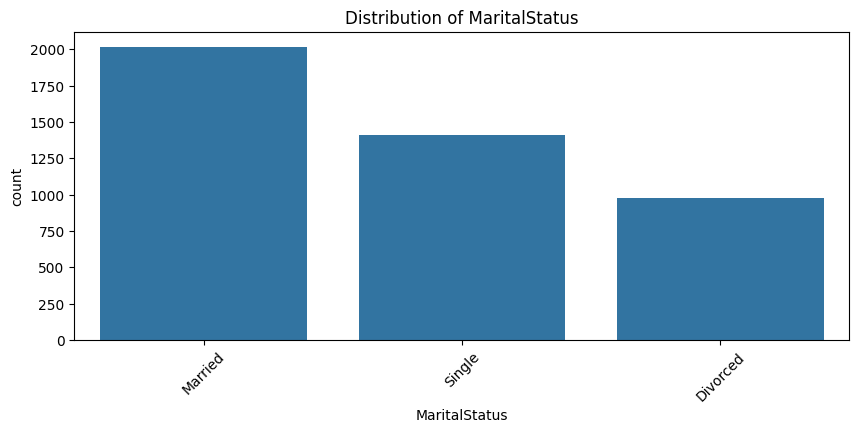

In [11]:
for column in numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(general_data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=general_data, x=column)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

<Figure size 1500x700 with 0 Axes>

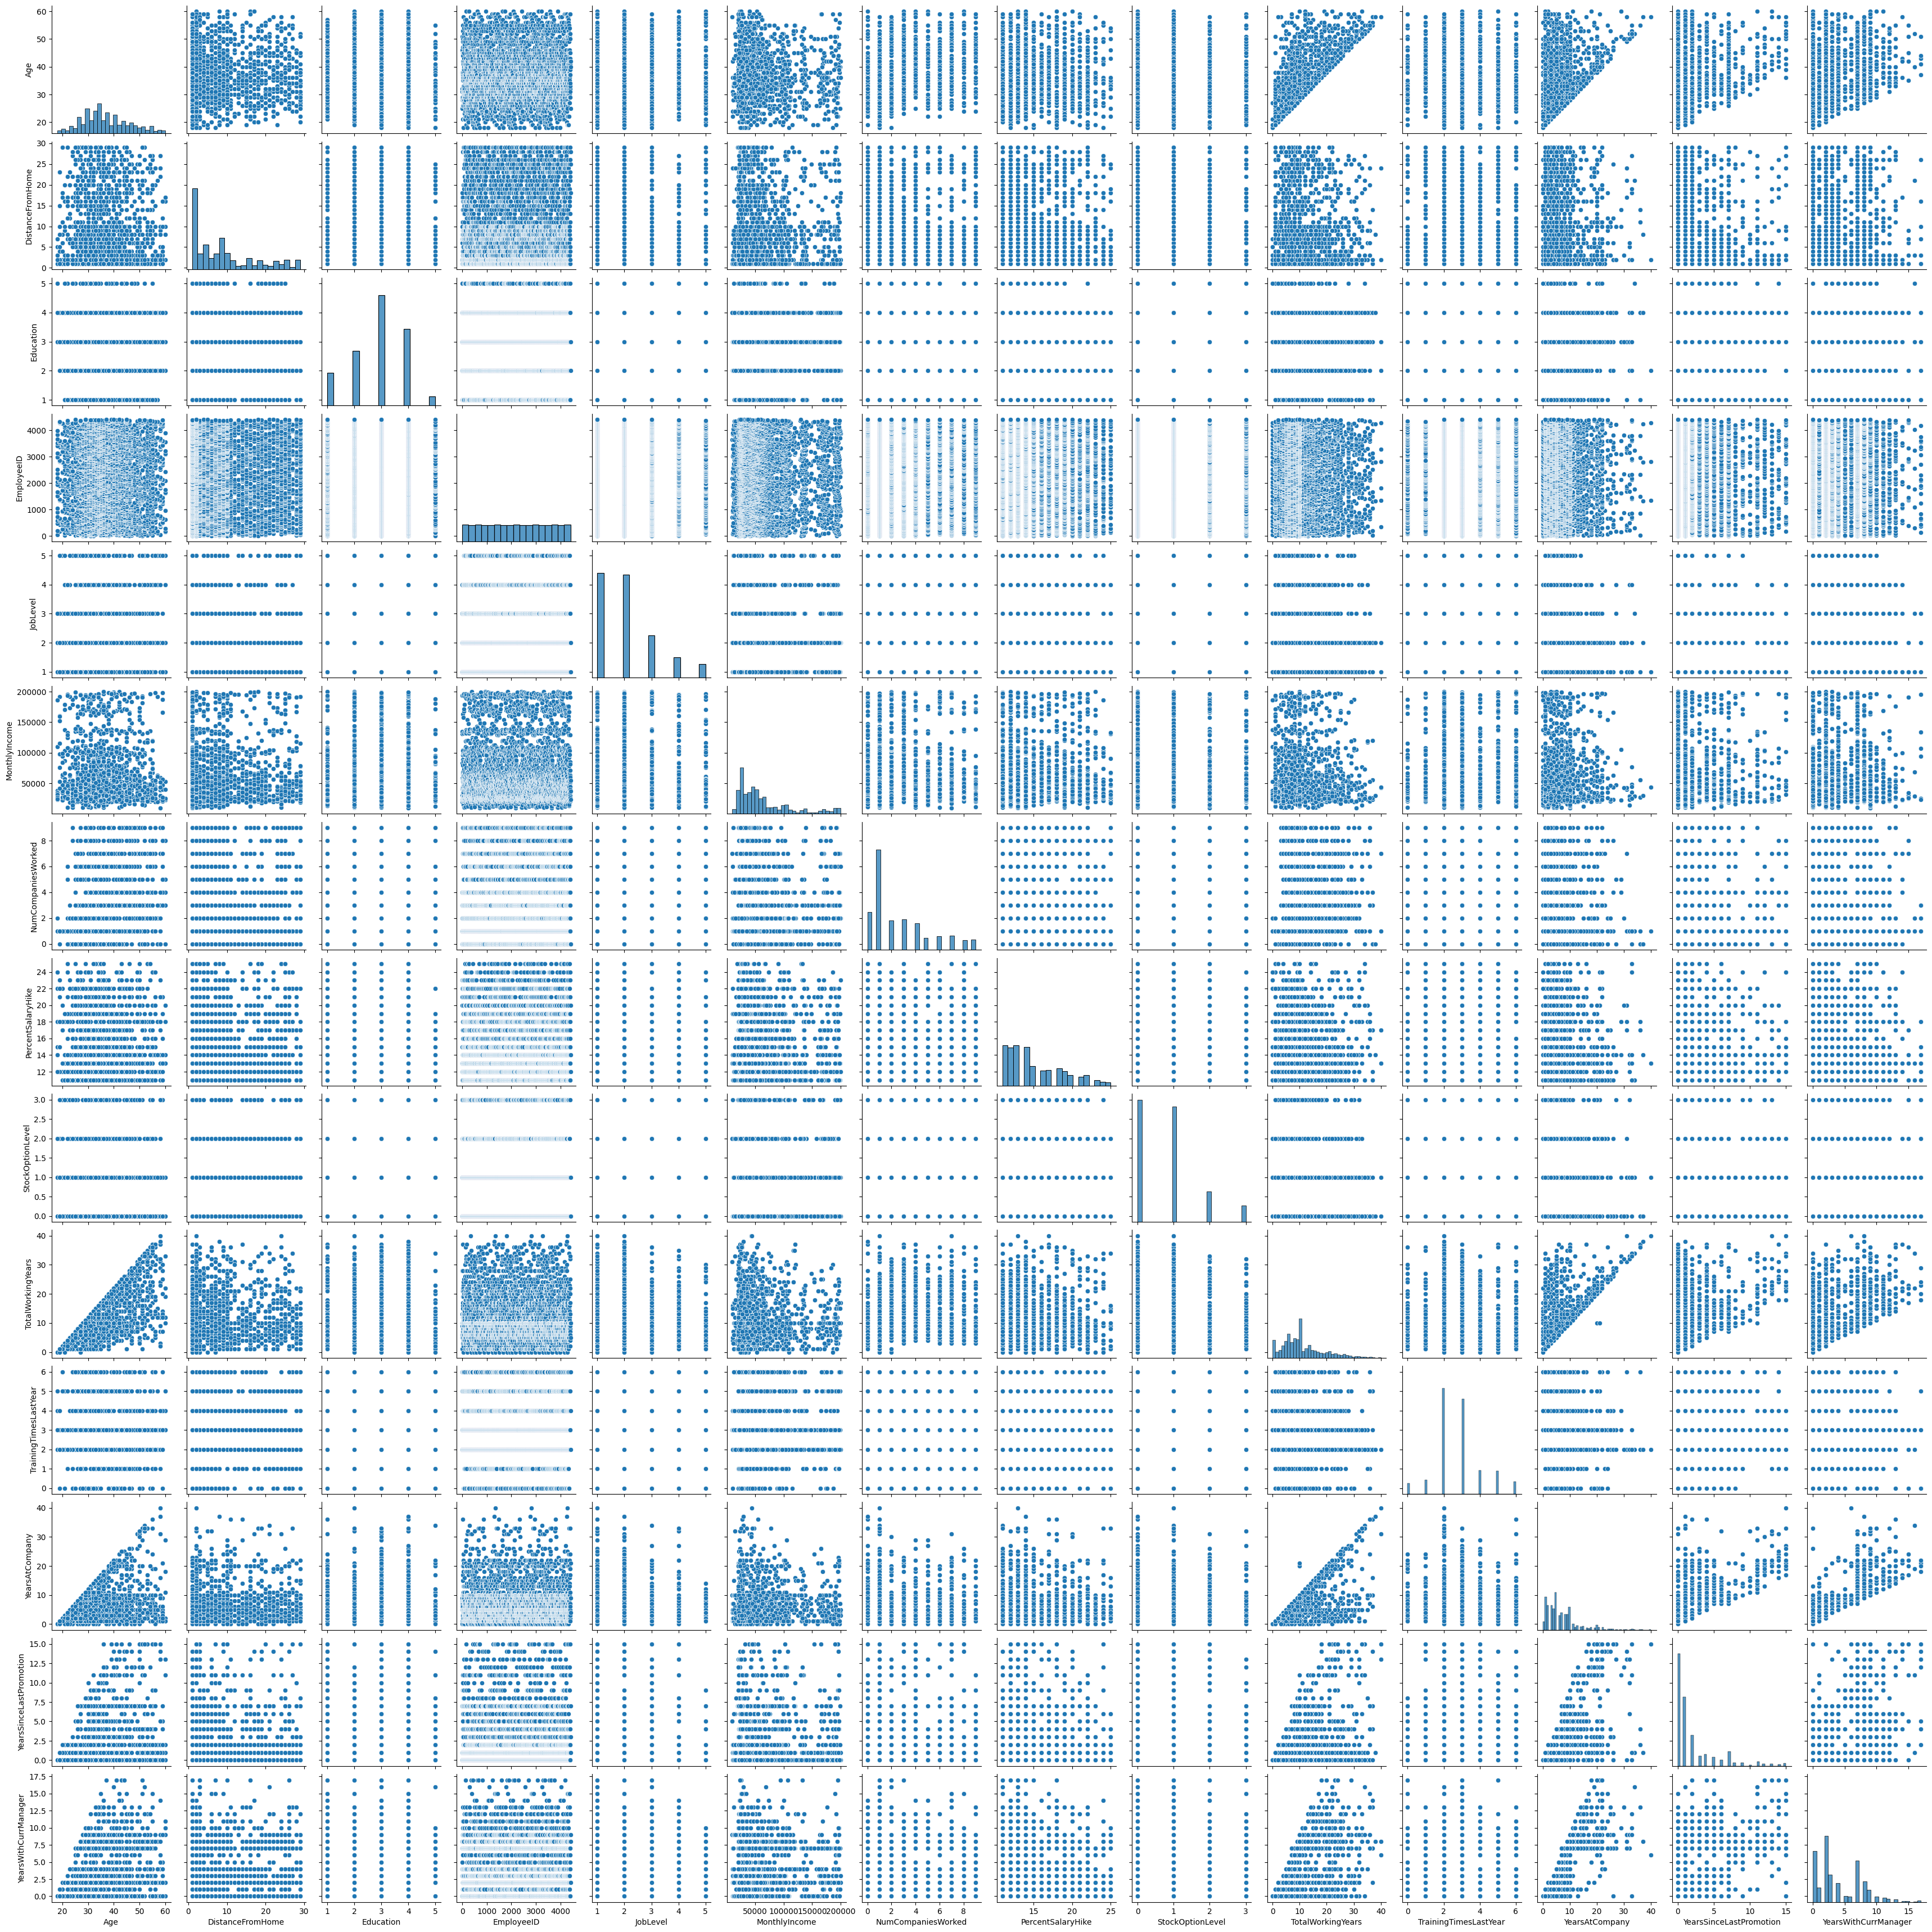

In [12]:
plt.figure(figsize=(15,7))
sns.pairplot(general_data[numerical_columns])
plt.show()

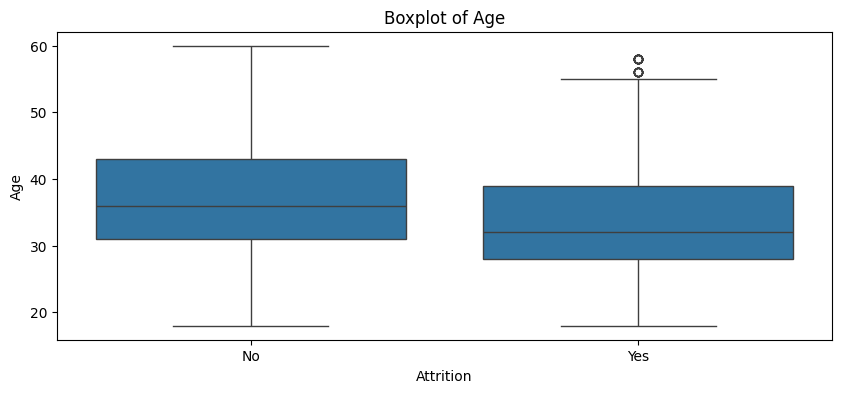

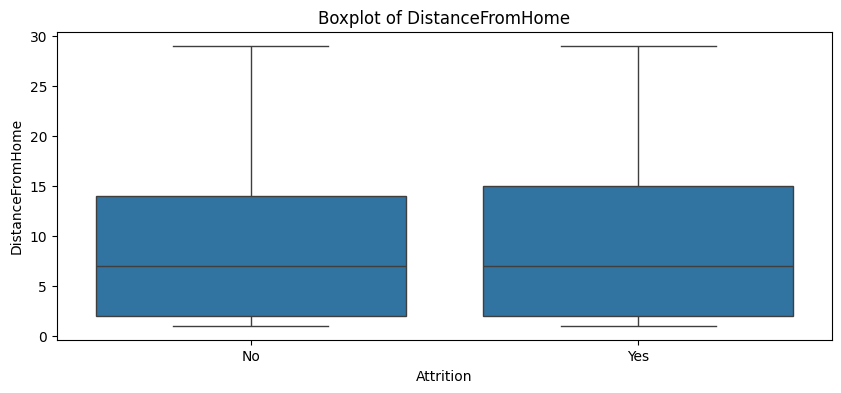

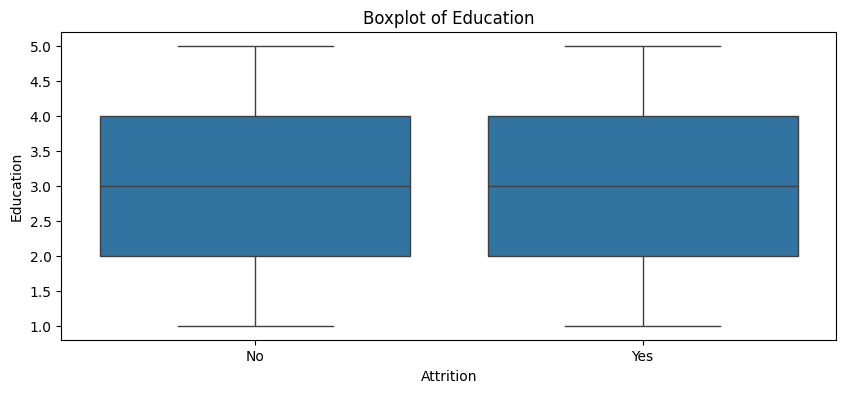

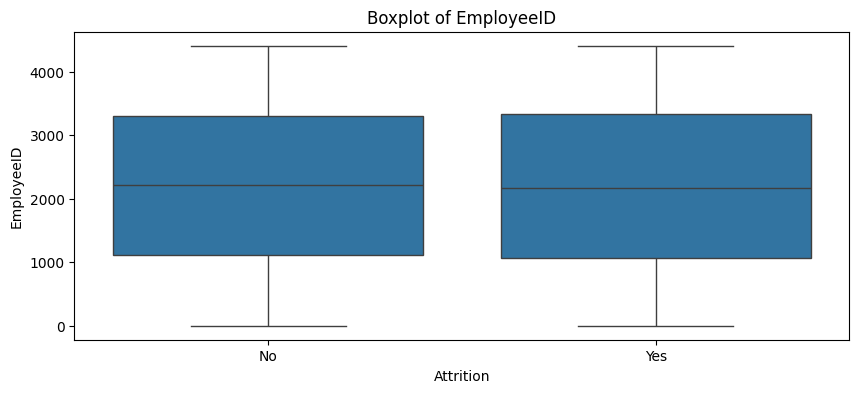

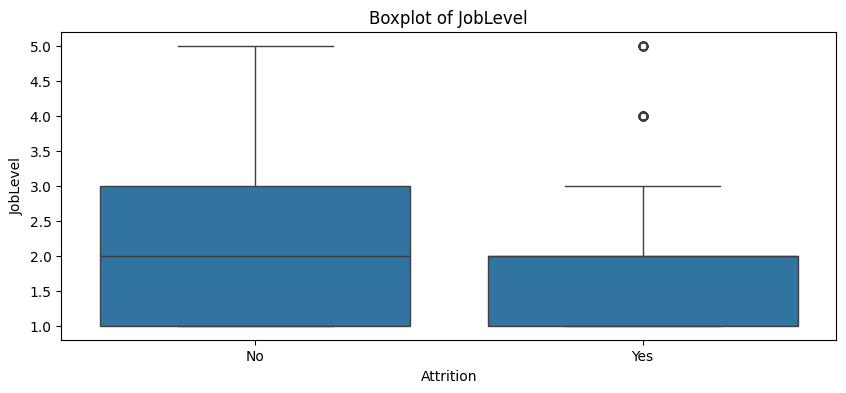

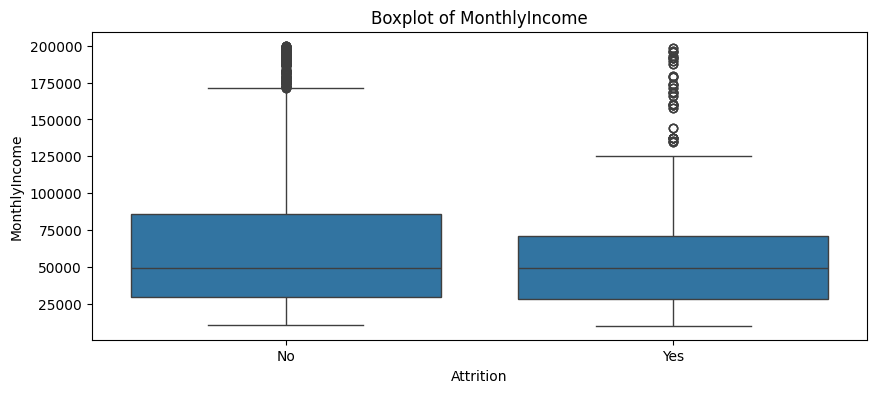

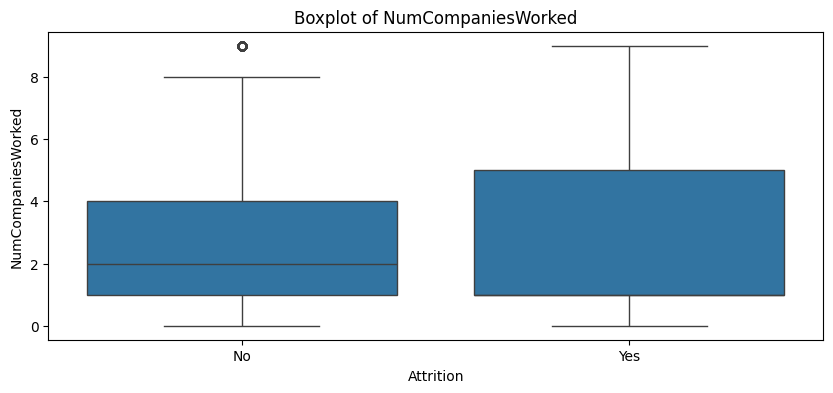

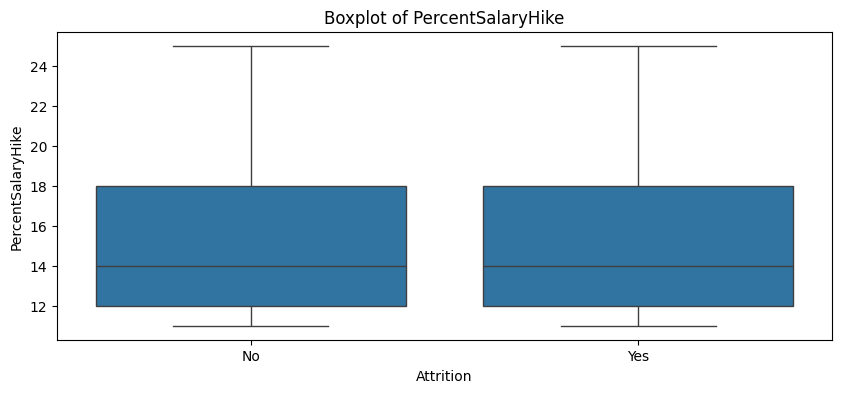

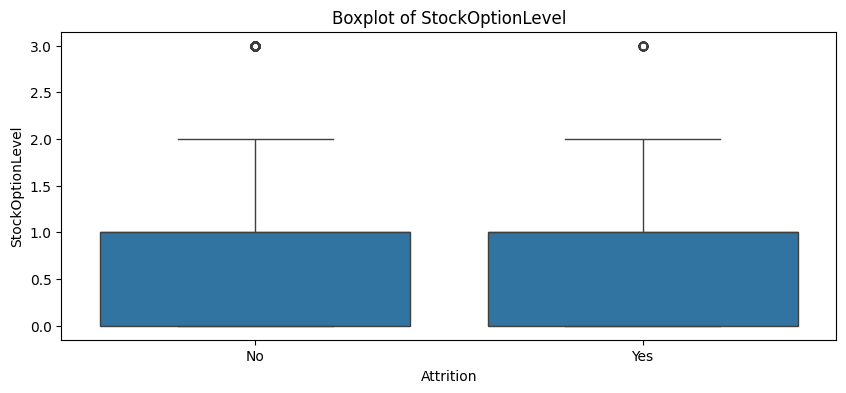

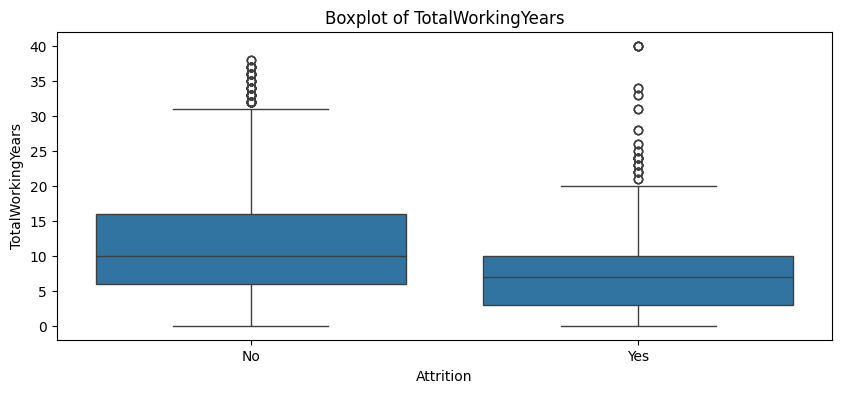

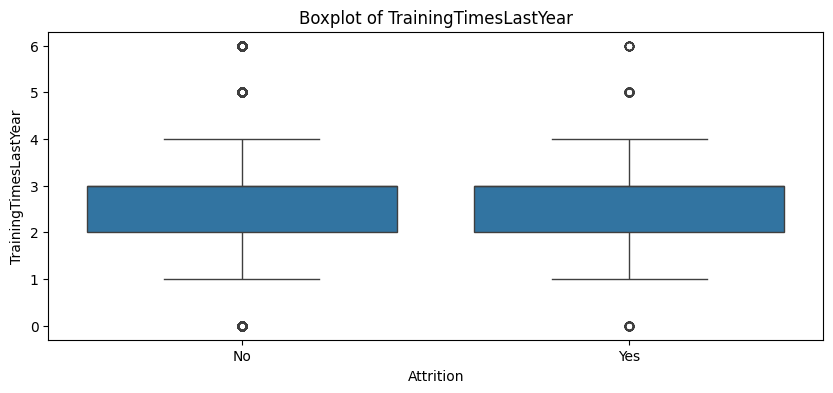

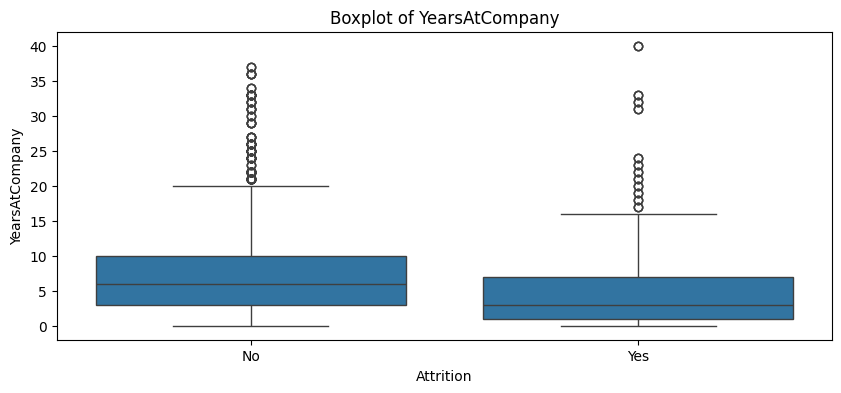

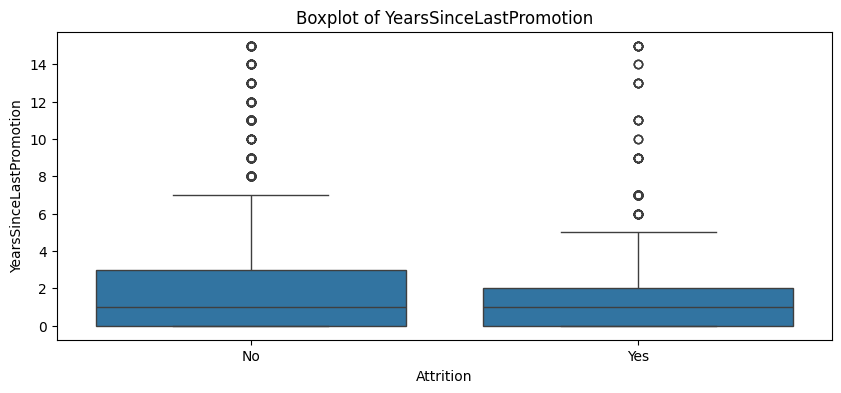

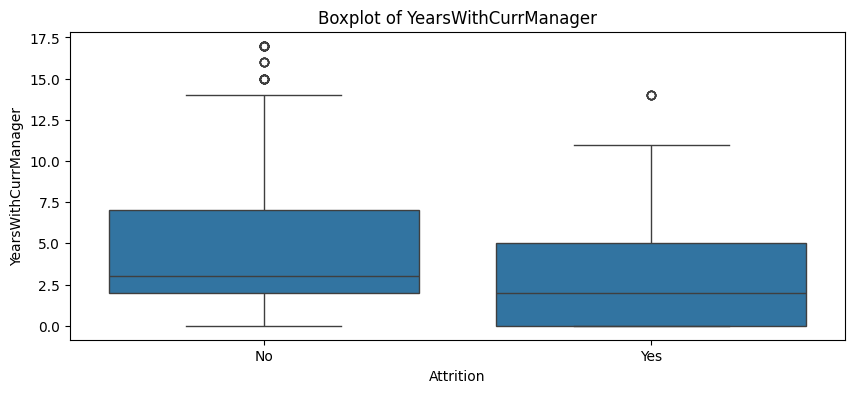

In [13]:
##boxplots
for column in numerical_columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=general_data['Attrition'], y=general_data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

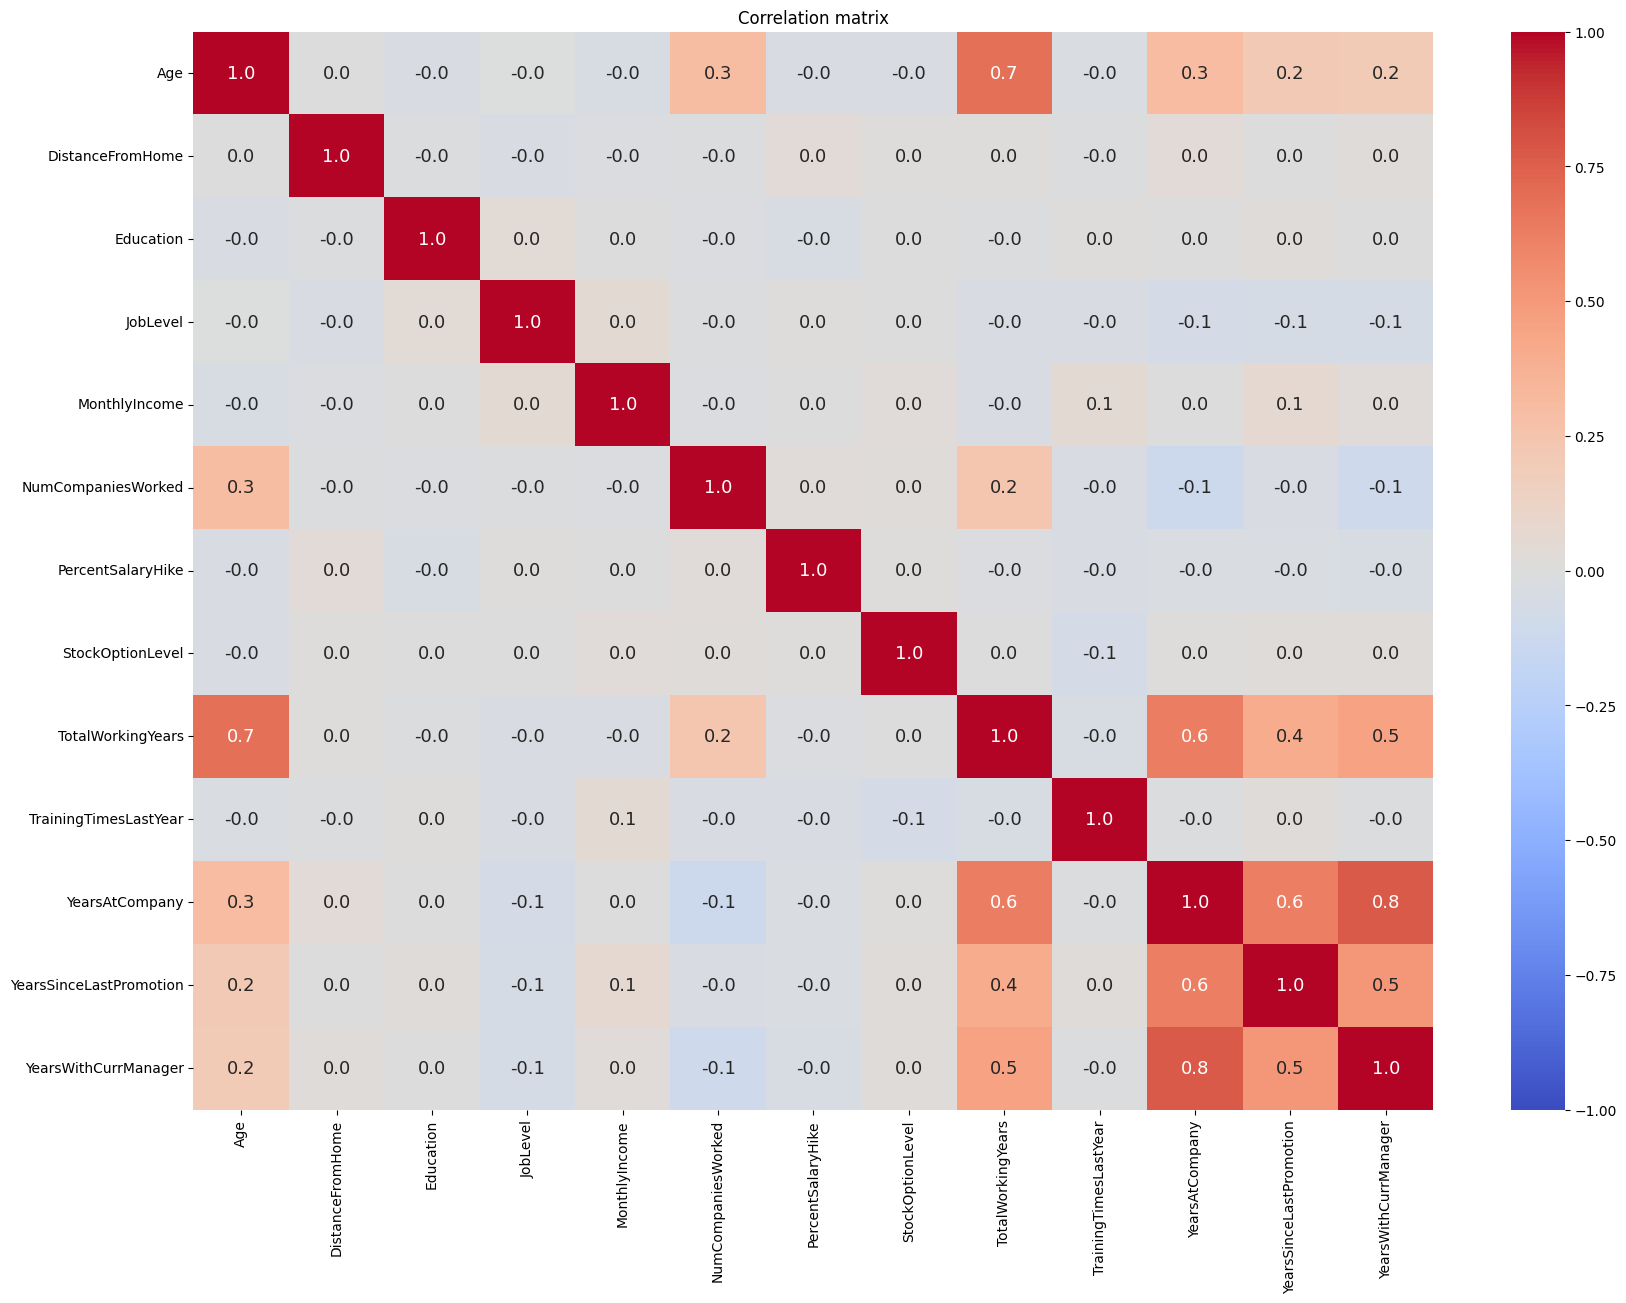

In [14]:
##Correlation
plt.figure(figsize=(20,14))
sns.heatmap(general_data[numerical_columns].drop('EmployeeID', axis=1).corr(),
            annot=True,
            annot_kws={'size':13},
            fmt='.1f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1
            )

plt.title("Correlation matrix")
plt.show()
            
    

In [15]:
print(categorical_columns)


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus'],
      dtype='object')


In [16]:
general_data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,Married,131160,1.0,11,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,Single,41890,0.0,23,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,Married,193280,1.0,15,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,Married,83210,3.0,11,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,Single,23420,4.0,12,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,No,Travel_Rarely,Research & Development,5,4,Medical,4406,Female,1,...,Single,60290,3.0,17,1,10.0,5,3,0,2
4406,29,No,Travel_Rarely,Research & Development,2,4,Medical,4407,Male,1,...,Divorced,26790,2.0,15,0,10.0,2,3,0,2
4407,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,Male,2,...,Married,37020,0.0,20,0,5.0,4,4,1,2
4408,42,No,Travel_Rarely,Sales,18,2,Medical,4409,Male,1,...,Divorced,23980,0.0,14,1,10.0,2,9,7,8


In [17]:
shape = general_data.shape[0]
general_data.Attrition.value_counts()/general_data.shape

Attrition
No      0.838776
Yes    33.857143
Name: count, dtype: float64

### Observations from general_data.csv

1. Attrition has positive correlation with marital status, and negative correlation with total working years, Years at compant and years with current manager. This might mean that more people ....
2. It is true that turnover is about 15% each year - 0.16

## Manager Survey data

In [18]:
## manager questionnaire
msd= pd.read_csv("datasets/manager_survey_data.csv")
msd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


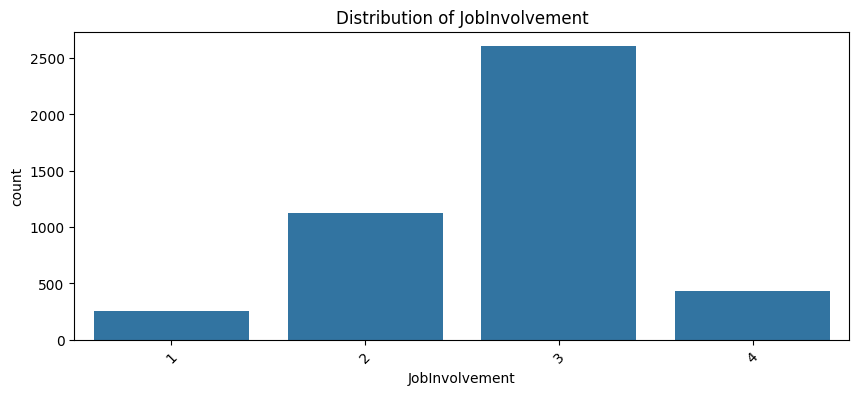

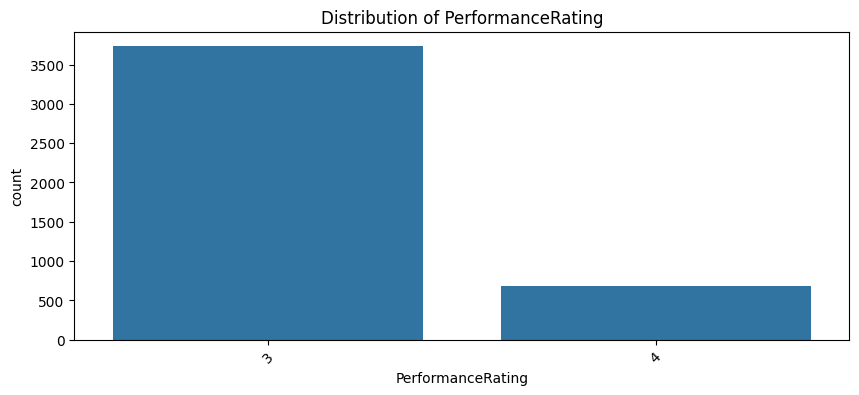

In [19]:
#Distributions of JobInvolvement, PerformanceRating
plt.figure(figsize=(10, 4))
sns.countplot(data=msd, x='JobInvolvement')
plt.title('Distribution of JobInvolvement')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=msd, x='PerformanceRating')
plt.title('Distribution of PerformanceRating')
plt.xticks(rotation=45)
plt.show()

In [20]:
msd['PerformanceRating'].value_counts()

PerformanceRating
3    3732
4     678
Name: count, dtype: int64

In [21]:
all_data = pd.merge(general_data, msd, on='EmployeeID', how='inner')
all_data.head(10)
print(all_data.shape)

(4410, 23)


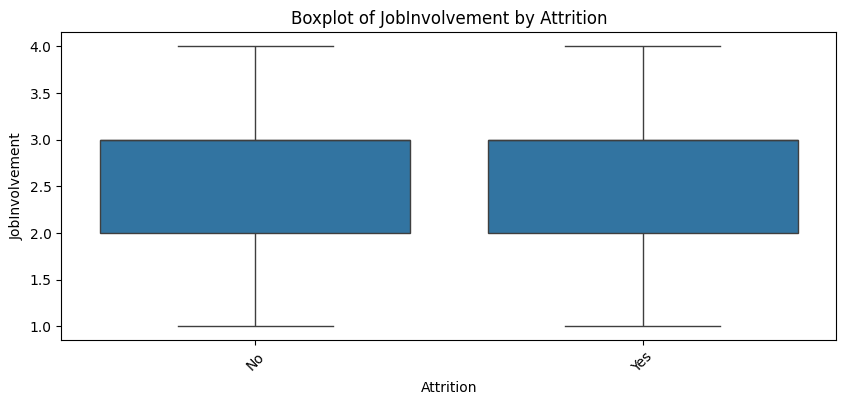

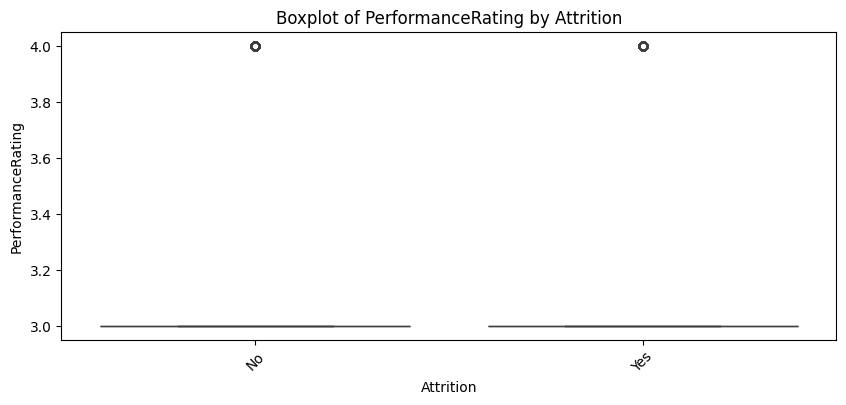

In [22]:
for column in msd.columns.drop("EmployeeID"):  # Loop through columns except 'EmployeeID'
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=all_data["Attrition"], y=all_data[column])  # Use time_data[column]
    plt.title(f"Boxplot of {column} by Attrition")
    plt.xticks(rotation=45)
    plt.show()

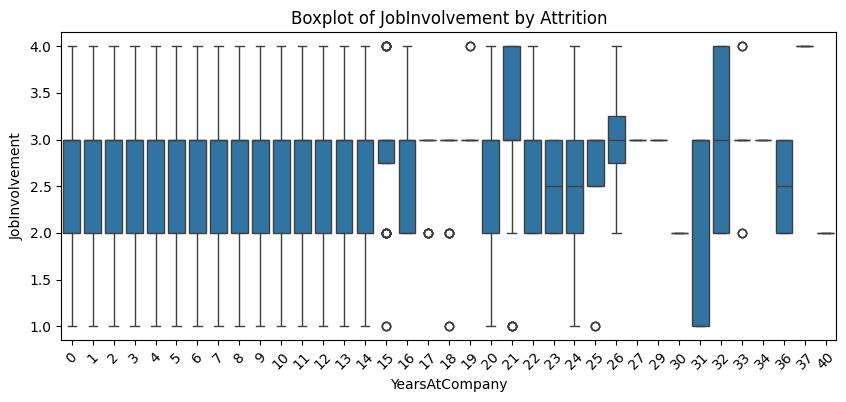

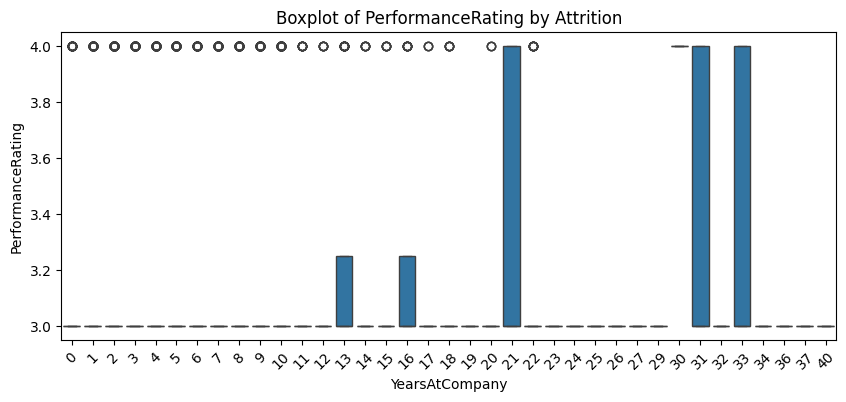

In [23]:
for column in msd.columns.drop("EmployeeID"):  # Loop through columns except 'EmployeeID'
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=all_data["YearsAtCompany"], y=all_data[column])  # Use time_data[column]
    plt.title(f"Boxplot of {column} by Attrition")
    plt.xticks(rotation=45)
    plt.show()

### Observations from general data and manager data

1. Job Involvement is almost equal, may not be a detrmining factor.
2. While comparing msd dataset with Years at company, we can deduce that job involvement is constant from 0-15 years, and performance rating is higher for more time at the company.

## Employee Survey data

In [24]:
## Employee survey data
esd = pd.read_csv("datasets/employee_survey_data.csv")
esd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


In [25]:
esd = esd.fillna(esd.mode().iloc[0])
print(esd.isnull().sum())
esd.head()

EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
dtype: int64


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


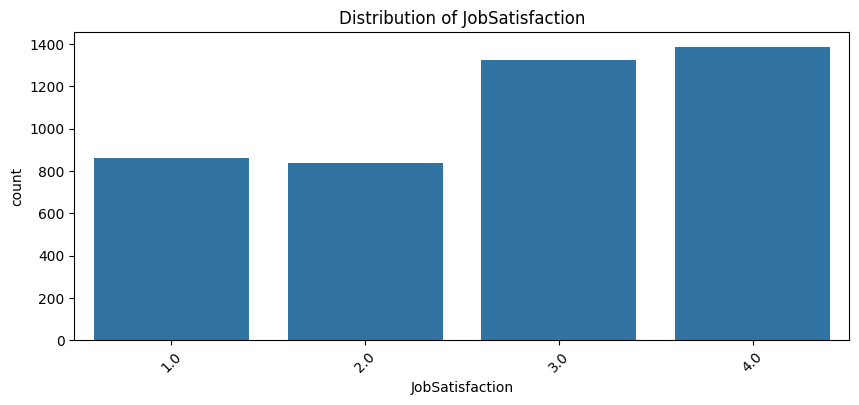

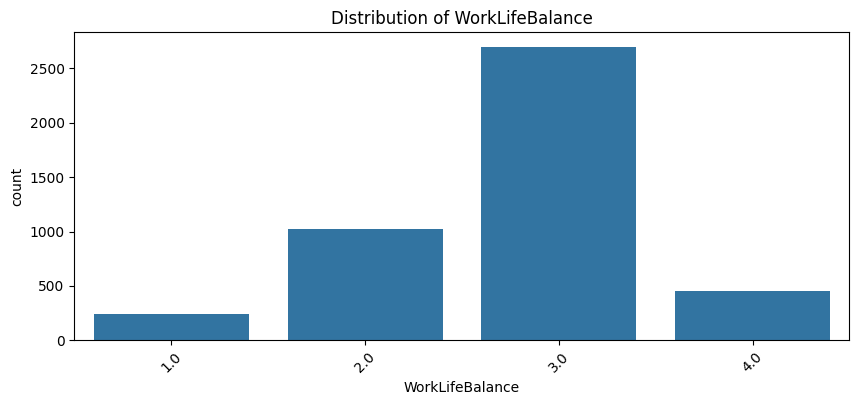

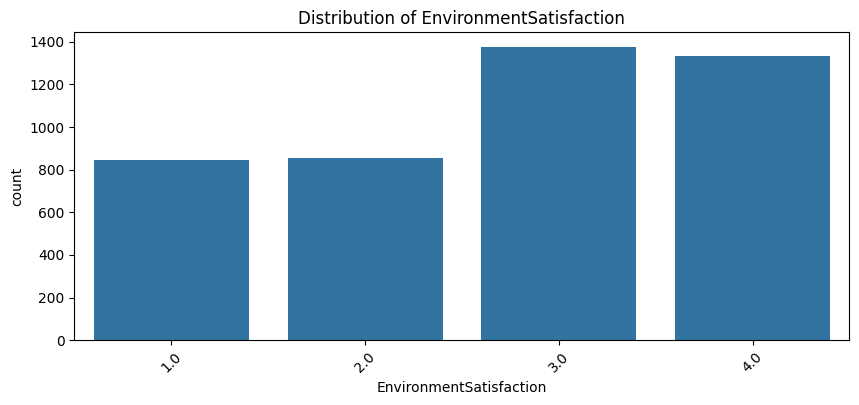

In [26]:
#Distributions
plt.figure(figsize=(10, 4))
sns.countplot(data=esd, x='JobSatisfaction')
plt.title('Distribution of JobSatisfaction')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=esd, x='WorkLifeBalance')
plt.title('Distribution of WorkLifeBalance')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=esd, x='EnvironmentSatisfaction')
plt.title('Distribution of EnvironmentSatisfaction')
plt.xticks(rotation=45)
plt.show()

In [27]:
all_data = pd.merge(all_data, esd, on='EmployeeID', how='inner')
all_data.head(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,1.0,6,1,0,0,3,3,3.0,4.0,2.0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,6.0,3,5,1,4,2,4,3.0,2.0,4.0
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,5.0,2,5,0,3,3,3,2.0,2.0,1.0
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,13.0,5,8,7,5,2,3,4.0,4.0,3.0
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,9.0,2,6,0,4,3,3,4.0,1.0,3.0
5,46,No,Travel_Rarely,Research & Development,8,3,Life Sciences,6,Female,4,...,28.0,5,7,7,7,3,3,3.0,2.0,2.0
6,28,Yes,Travel_Rarely,Research & Development,11,2,Medical,7,Male,2,...,5.0,2,0,0,0,3,4,1.0,3.0,1.0
7,29,No,Travel_Rarely,Research & Development,18,3,Life Sciences,8,Male,2,...,10.0,2,0,0,0,3,4,1.0,2.0,3.0
8,31,No,Travel_Rarely,Research & Development,1,3,Life Sciences,9,Male,3,...,10.0,2,9,7,8,3,4,2.0,4.0,3.0
9,25,No,Non-Travel,Research & Development,7,4,Medical,10,Female,4,...,6.0,2,6,1,5,3,3,2.0,1.0,3.0


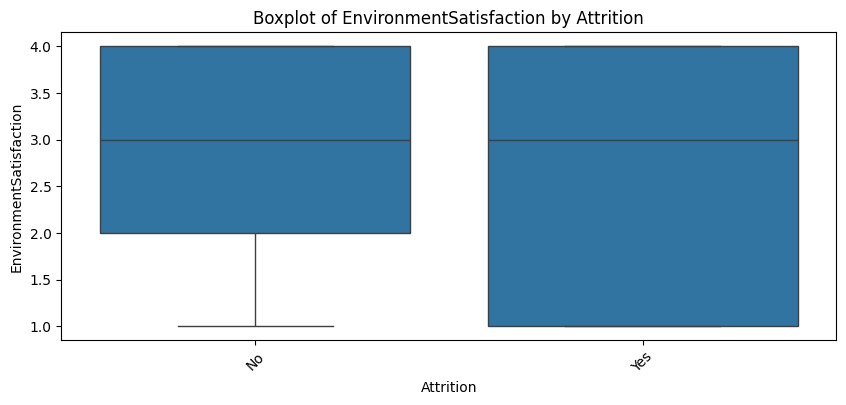

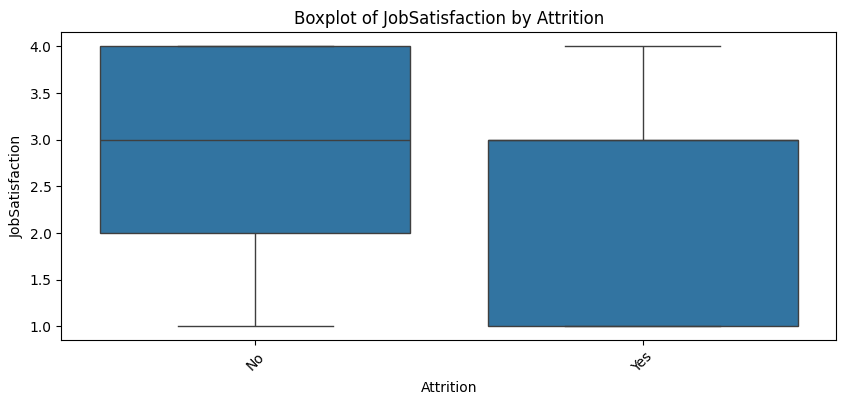

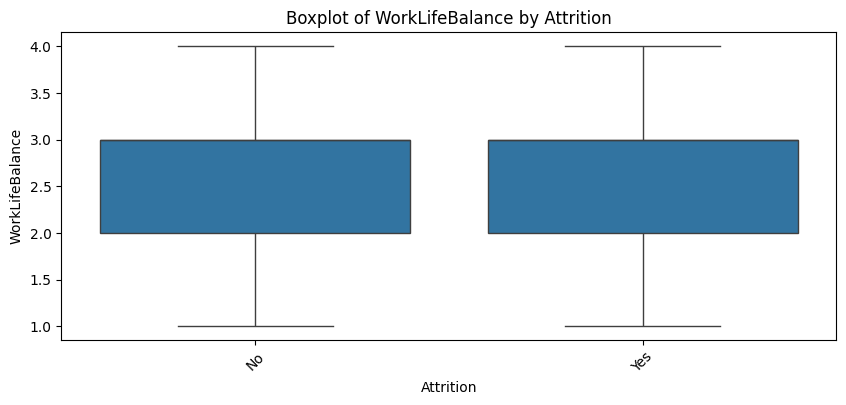

In [28]:
for column in esd.columns.drop("EmployeeID"):
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=all_data["Attrition"], y=all_data[column])
    plt.title(f"Boxplot of {column} by Attrition")
    plt.xticks(rotation=45)
    plt.show()


### Observations from all data and Employee survey data

1. Job satisfaction and environment satisfaction seems an important factor for departure.

## In and Out Time data

In [29]:
in_time = pd.read_csv("datasets/in_time.csv")
out_time = pd.read_csv("datasets/out_time.csv")

In [30]:
in_time

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,4406,NaN,2015-01-02 09:20:32,2015-01-05 10:17:53,2015-01-06 10:26:51,2015-01-07 10:06:58,2015-01-08 09:45:06,2015-01-09 09:49:24,2015-01-12 09:37:10,2015-01-13 09:25:02,...,2015-12-18 10:01:06,2015-12-21 10:25:25,2015-12-22 10:16:11,2015-12-23 10:04:40,2015-12-24 09:45:40,NaN,2015-12-28 10:15:39,2015-12-29 10:10:09,2015-12-30 09:28:19,2015-12-31 10:00:12
4406,4407,NaN,2015-01-02 10:03:41,NaN,2015-01-06 09:44:00,2015-01-07 09:42:10,2015-01-08 10:00:57,2015-01-09 09:44:04,2015-01-12 10:07:32,2015-01-13 10:05:11,...,2015-12-18 09:27:32,2015-12-21 09:41:24,2015-12-22 09:50:30,2015-12-23 10:32:21,2015-12-24 09:47:41,NaN,2015-12-28 09:54:23,2015-12-29 10:13:32,2015-12-30 10:21:09,2015-12-31 10:09:48
4407,4408,NaN,2015-01-02 10:01:01,2015-01-05 09:33:00,2015-01-06 09:49:17,2015-01-07 10:28:12,2015-01-08 09:47:38,2015-01-09 10:01:03,2015-01-12 09:49:12,2015-01-13 09:47:10,...,2015-12-18 10:00:57,2015-12-21 09:51:07,2015-12-22 10:02:10,2015-12-23 09:58:29,2015-12-24 09:56:05,NaN,2015-12-28 09:59:24,NaN,2015-12-30 10:02:36,2015-12-31 10:03:30
4408,4409,NaN,2015-01-02 10:17:05,2015-01-05 10:02:27,2015-01-06 10:12:50,2015-01-07 10:12:31,2015-01-08 09:42:57,NaN,2015-01-12 10:00:38,2015-01-13 09:48:03,...,2015-12-18 09:54:33,2015-12-21 10:01:08,2015-12-22 10:10:19,2015-12-23 09:42:30,2015-12-24 09:56:05,NaN,2015-12-28 09:55:25,2015-12-29 09:54:42,2015-12-30 10:15:44,2015-12-31 09:56:47


In [31]:
out_time

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,4406,NaN,2015-01-02 17:27:37,2015-01-05 19:08:20,2015-01-06 18:50:49,2015-01-07 18:57:40,2015-01-08 17:58:31,2015-01-09 18:06:15,2015-01-12 17:58:48,2015-01-13 18:10:35,...,2015-12-18 18:06:05,2015-12-21 18:35:06,2015-12-22 18:33:44,2015-12-23 18:40:56,2015-12-24 18:21:29,NaN,2015-12-28 18:44:35,2015-12-29 19:14:38,2015-12-30 18:24:56,2015-12-31 18:30:41
4406,4407,NaN,2015-01-02 16:19:01,NaN,2015-01-06 15:07:37,2015-01-07 15:25:50,2015-01-08 16:12:33,2015-01-09 15:26:56,2015-01-12 16:10:42,2015-01-13 16:22:43,...,2015-12-18 15:23:02,2015-12-21 15:31:14,2015-12-22 15:45:59,2015-12-23 16:38:59,2015-12-24 15:47:15,NaN,2015-12-28 15:34:34,2015-12-29 16:47:02,2015-12-30 16:03:17,2015-12-31 16:18:39
4407,4408,NaN,2015-01-02 17:17:35,2015-01-05 17:08:07,2015-01-06 17:27:46,2015-01-07 18:27:22,2015-01-08 17:05:25,2015-01-09 17:02:57,2015-01-12 17:35:45,2015-01-13 17:15:52,...,2015-12-18 17:48:05,2015-12-21 17:43:05,2015-12-22 17:47:23,2015-12-23 17:43:37,2015-12-24 17:20:12,NaN,2015-12-28 17:43:28,NaN,2015-12-30 17:48:14,2015-12-31 18:08:55
4408,4409,NaN,2015-01-02 19:48:37,2015-01-05 19:37:40,2015-01-06 20:00:08,2015-01-07 19:35:59,2015-01-08 18:55:13,NaN,2015-01-12 19:18:17,2015-01-13 19:24:02,...,2015-12-18 19:52:44,2015-12-21 19:21:35,2015-12-22 19:32:40,2015-12-23 18:57:00,2015-12-24 19:37:57,NaN,2015-12-28 19:58:36,2015-12-29 18:55:26,2015-12-30 19:37:22,2015-12-31 19:33:45


In [32]:
in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

In [33]:
in_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


In [34]:
out_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


### Dealing with Time series data

1. Figure out number of days worked
2. Number of hours worked per day
3. Period of absence
4. Number of leaves outside working hrs (9-11, 4-7)


In [35]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
in_time.isnull().sum()

EmployeeID       0
2015-01-01    4410
2015-01-02     209
2015-01-05     206
2015-01-06     228
              ... 
2015-12-25    4410
2015-12-28     234
2015-12-29     230
2015-12-30     265
2015-12-31     213
Length: 262, dtype: int64

In [37]:
in_time.iloc[:, 1:] = in_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')
out_time.iloc[:, 1:] = out_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')

In [38]:
days_worked = in_time.iloc[:, 1:].notna().sum(axis=1)
days_worked.tail()

4405    243
4406    241
4407    231
4408    241
4409    232
dtype: int64

In [39]:
hours_worked = out_time.iloc[:, 1:] - in_time.iloc[:,1:]
hours_worked = hours_worked.applymap(lambda x: x.total_seconds()/3600 if pd.notnull(x) else 0)

In [40]:
hpd = hours_worked.sum(axis=1)/ days_worked
hpd

0       7.373651
1       7.718969
2       7.013240
3       7.193678
4       8.006175
          ...   
4405    8.522277
4406    6.092954
4407    7.706632
4408    9.492595
4409    6.988948
Length: 4410, dtype: float64

In [41]:
def absence(series):
    absences = series.isna().astype(int)
    return absences.groupby((absences != absences.shift()).cumsum()).sum().max()

longest_absence = in_time.iloc[:, 1:].apply(absence, axis=1)
print(longest_absence)
longest_absence.describe()

0       3
1       3
2       3
3       4
4       3
       ..
4405    3
4406    3
4407    3
4408    3
4409    3
Length: 4410, dtype: int64


count    4410.000000
mean        3.116100
std         0.346239
min         3.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         6.000000
dtype: float64

In [42]:
time_data = pd.DataFrame({
    'EmployeeID': in_time['EmployeeID'],
    'WorkDays': days_worked,
    'HoursPerDay': hpd,
    'LongestAbsence': longest_absence
})

time_data.info()
time_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   EmployeeID      4410 non-null   int64  
 1   WorkDays        4410 non-null   int64  
 2   HoursPerDay     4410 non-null   float64
 3   LongestAbsence  4410 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 137.9 KB


,EmployeeID,WorkDays,HoursPerDay,LongestAbsence
count,4410.000000,4410.000000,4410.000000,4410.000000
mean,2205.500000,236.265306,7.700792,3.116100
std,1273.201673,5.503779,1.340218,0.346239
min,1.000000,225.000000,5.950504,3.000000
25%,1103.250000,232.000000,6.673333,3.000000
50%,2205.500000,236.000000,7.406761,3.000000
75%,3307.750000,241.000000,8.368703,3.000000
max,4410.000000,248.000000,11.030960,6.000000


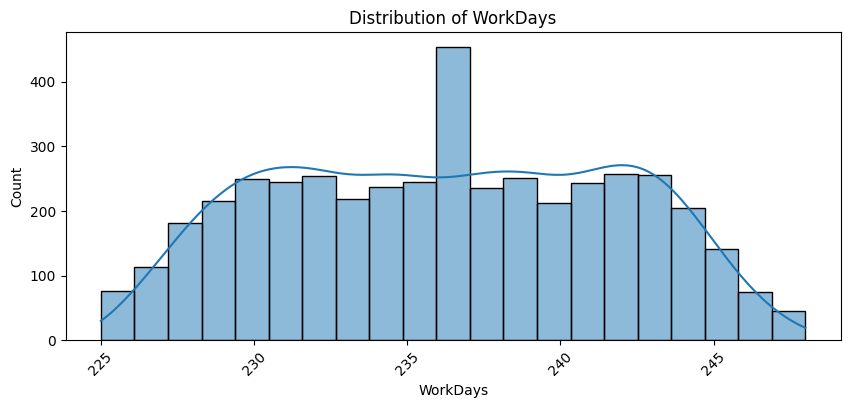

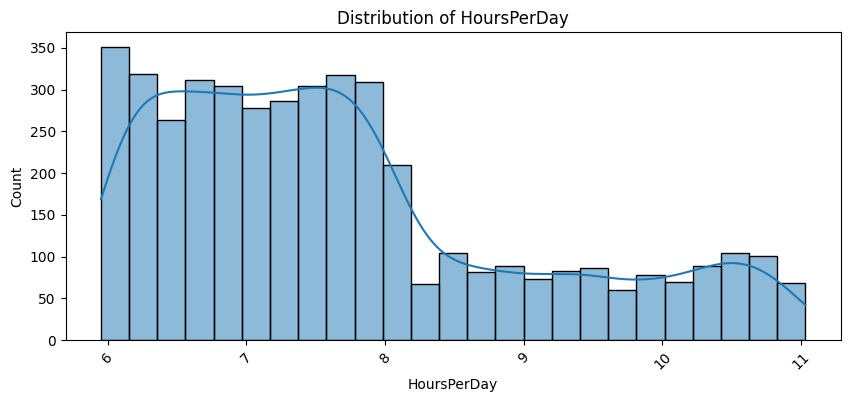

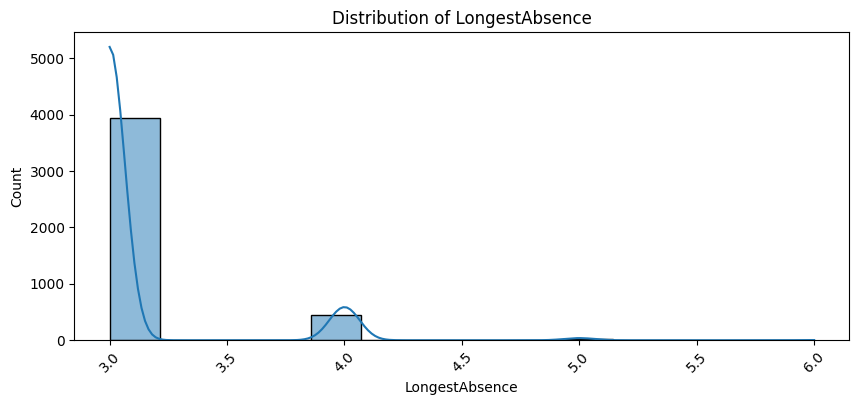

In [43]:
for column in time_data.columns.drop('EmployeeID'):
    plt.figure(figsize=(10, 4))
    sns.histplot(time_data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

In [44]:
print(all_data.shape)

(4410, 26)


In [45]:
all_data = pd.merge(all_data, time_data, on='EmployeeID', how='inner')
all_data.head(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,0,0,3,3,3.0,4.0,2.0,232,7.373651,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,1,4,2,4,3.0,2.0,4.0,236,7.718969,3
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,0,3,3,3,2.0,2.0,1.0,242,7.013240,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,7,5,2,3,4.0,4.0,3.0,235,7.193678,4
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,0,4,3,3,4.0,1.0,3.0,245,8.006175,3
5,46,No,Travel_Rarely,Research & Development,8,3,Life Sciences,6,Female,4,...,7,7,3,3,3.0,2.0,2.0,237,10.796096,3
6,28,Yes,Travel_Rarely,Research & Development,11,2,Medical,7,Male,2,...,0,0,3,4,1.0,3.0,1.0,232,6.923570,3
7,29,No,Travel_Rarely,Research & Development,18,3,Life Sciences,8,Male,2,...,0,0,3,4,1.0,2.0,3.0,243,6.725621,4
8,31,No,Travel_Rarely,Research & Development,1,3,Life Sciences,9,Male,3,...,7,8,3,4,2.0,4.0,3.0,230,7.236499,4
9,25,No,Non-Travel,Research & Development,7,4,Medical,10,Female,4,...,1,5,3,3,2.0,1.0,3.0,234,7.080088,4


In [46]:
print(all_data.shape)

(4410, 29)


In [47]:
all_data.head(15)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,0,0,3,3,3.0,4.0,2.0,232,7.373651,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,1,4,2,4,3.0,2.0,4.0,236,7.718969,3
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,0,3,3,3,2.0,2.0,1.0,242,7.013240,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,7,5,2,3,4.0,4.0,3.0,235,7.193678,4
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,0,4,3,3,4.0,1.0,3.0,245,8.006175,3
5,46,No,Travel_Rarely,Research & Development,8,3,Life Sciences,6,Female,4,...,7,7,3,3,3.0,2.0,2.0,237,10.796096,3
6,28,Yes,Travel_Rarely,Research & Development,11,2,Medical,7,Male,2,...,0,0,3,4,1.0,3.0,1.0,232,6.923570,3
7,29,No,Travel_Rarely,Research & Development,18,3,Life Sciences,8,Male,2,...,0,0,3,4,1.0,2.0,3.0,243,6.725621,4
8,31,No,Travel_Rarely,Research & Development,1,3,Life Sciences,9,Male,3,...,7,8,3,4,2.0,4.0,3.0,230,7.236499,4
9,25,No,Non-Travel,Research & Development,7,4,Medical,10,Female,4,...,1,5,3,3,2.0,1.0,3.0,234,7.080088,4


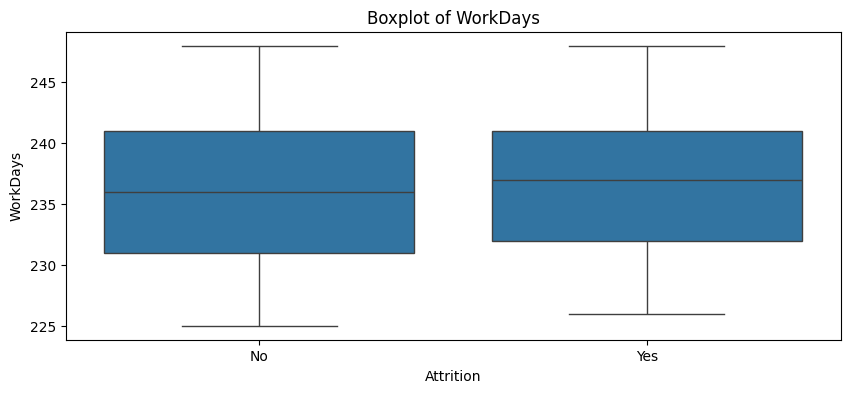

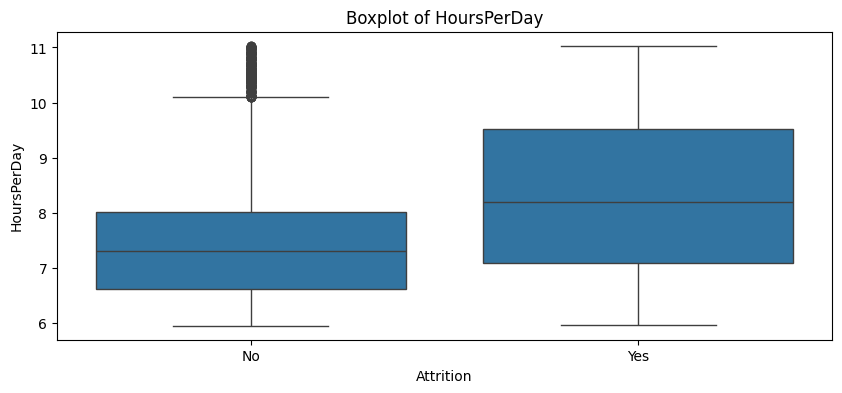

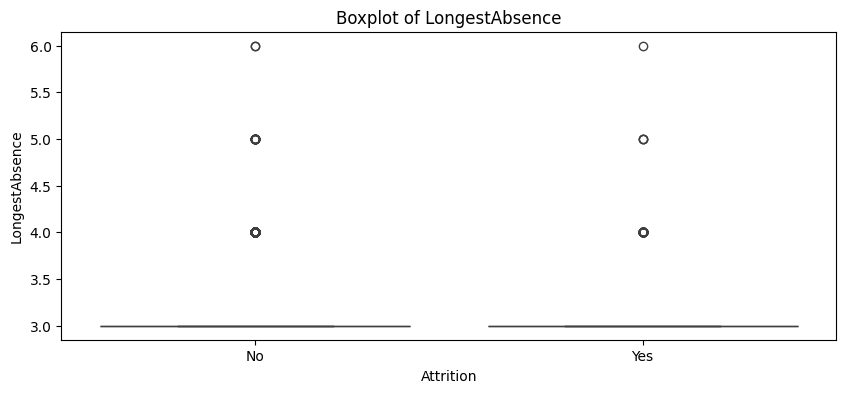

In [48]:
for column in time_data.columns.drop('EmployeeID'):
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=all_data["Attrition"], y=all_data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [49]:
##encoding and scaling
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeID               4410 non-null   int64  
 8   Gender                   4410 non-null   object 
 9   JobLevel                 4410 non-null   int64  
 10  JobRole                  4410 non-null   object 
 11  MaritalStatus            4410 non-null   object 
 12  MonthlyIncome            4410 non-null   int64  
 13  NumCompaniesWorked       4410 non-null   float64
 14  PercentSalaryHike       

In [50]:
import os
os.makedirs("datasets", exist_ok=True)
all_data.to_csv("datasets/all_data.csv", index=False)

In [51]:
all_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,0,0,3,3,3.0,4.0,2.0,232,7.373651,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,1,4,2,4,3.0,2.0,4.0,236,7.718969,3
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,0,3,3,3,2.0,2.0,1.0,242,7.013240,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,7,5,2,3,4.0,4.0,3.0,235,7.193678,4
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,0,4,3,3,4.0,1.0,3.0,245,8.006175,3


## Encoding and Standard Scaling

In [52]:
categorical_features = all_data.select_dtypes(include=['object']).columns.drop(['Attrition'])
numerical_features = all_data.select_dtypes(exclude=['object']).columns.drop(['EmployeeID'])

In [53]:
categorical_features

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='object')

In [54]:
numerical_features

Index(['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement',
       'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'WorkDays', 'HoursPerDay', 'LongestAbsence'],
      dtype='object')

In [55]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

ss=StandardScaler()
ohe = OneHotEncoder()
encoder = OrdinalEncoder()


In [56]:
num_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', ss)
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", encoder, categorical_features)
])

all_data_prepared = pd.DataFrame(full_pipeline.fit_transform(all_data))
num_feature_names = numerical_features
cat_feature_names = full_pipeline.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) + list(cat_feature_names)
all_data_prepared.columns = all_feature_names

In [57]:
print(all_data_prepared.shape)

(4410, 27)


In [58]:
all_data_prepared

,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,...,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus
0,1.541369,-0.393938,-0.891688,-0.961486,1.405136,-0.678464,-1.150554,-0.932014,-1.322079,2.483396,...,-1.085336,-0.775066,-0.244123,-0.335355,2.0,2.0,1.0,0.0,0.0,1.0
1,-0.648668,0.099639,-1.868426,-0.961486,-0.491661,-1.079486,2.129306,0.241988,-0.678877,0.155707,...,1.757749,-0.048210,0.013564,-0.335355,1.0,1.0,1.0,0.0,6.0,2.0
2,-0.539166,0.963398,1.061787,1.749610,2.725053,-0.678464,-0.057267,2.589994,-0.807517,-0.620189,...,-2.506879,1.042074,-0.513073,-0.335355,1.0,1.0,4.0,1.0,7.0,1.0
3,0.117845,-0.887515,2.038524,0.845911,0.386301,0.123580,-1.150554,2.589994,0.221606,1.707500,...,0.336206,-0.229924,-0.378424,2.553152,0.0,1.0,1.0,1.0,1.0,1.0
4,-0.539166,0.099639,-1.868426,-0.961486,-0.884109,0.524602,-0.877232,1.415991,-0.292956,-0.620189,...,0.336206,1.587216,0.227886,-0.335355,2.0,1.0,3.0,1.0,7.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,0.555852,-0.517332,1.061787,-0.961486,-0.100700,0.123580,0.489376,0.241988,-0.164315,1.707500,...,0.336206,1.223788,0.613019,-0.335355,2.0,1.0,3.0,0.0,6.0,2.0
4406,-0.867672,-0.887515,1.061787,-0.961486,-0.812504,-0.277442,-0.057267,-0.932014,-0.164315,-0.620189,...,0.336206,0.860360,-1.199820,-0.335355,2.0,1.0,3.0,1.0,2.0,0.0
4407,-1.305679,1.950552,-0.891688,-0.057788,-0.595138,-1.079486,1.309341,-0.932014,-0.807517,0.931603,...,0.336206,-0.956780,0.004358,-0.335355,2.0,1.0,1.0,1.0,7.0,1.0
4408,0.555852,1.086793,-0.891688,-0.961486,-0.872210,-1.079486,-0.330589,0.241988,-0.164315,-0.620189,...,0.336206,0.860360,1.337100,-0.335355,2.0,2.0,3.0,1.0,2.0,0.0


## Train and test splits

In [59]:
X = all_data_prepared
y = all_data['Attrition']
X.info()
X.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   float64
 1   DistanceFromHome         4410 non-null   float64
 2   Education                4410 non-null   float64
 3   JobLevel                 4410 non-null   float64
 4   MonthlyIncome            4410 non-null   float64
 5   NumCompaniesWorked       4410 non-null   float64
 6   PercentSalaryHike        4410 non-null   float64
 7   StockOptionLevel         4410 non-null   float64
 8   TotalWorkingYears        4410 non-null   float64
 9   TrainingTimesLastYear    4410 non-null   float64
 10  YearsAtCompany           4410 non-null   float64
 11  YearsSinceLastPromotion  4410 non-null   float64
 12  YearsWithCurrManager     4410 non-null   float64
 13  JobInvolvement           4410 non-null   float64
 14  PerformanceRating       

,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,...,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus
0,1.541369,-0.393938,-0.891688,-0.961486,1.405136,-0.678464,-1.150554,-0.932014,-1.322079,2.483396,...,-1.085336,-0.775066,-0.244123,-0.335355,2.0,2.0,1.0,0.0,0.0,1.0
1,-0.648668,0.099639,-1.868426,-0.961486,-0.491661,-1.079486,2.129306,0.241988,-0.678877,0.155707,...,1.757749,-0.048210,0.013564,-0.335355,1.0,1.0,1.0,0.0,6.0,2.0
2,-0.539166,0.963398,1.061787,1.749610,2.725053,-0.678464,-0.057267,2.589994,-0.807517,-0.620189,...,-2.506879,1.042074,-0.513073,-0.335355,1.0,1.0,4.0,1.0,7.0,1.0
3,0.117845,-0.887515,2.038524,0.845911,0.386301,0.123580,-1.150554,2.589994,0.221606,1.707500,...,0.336206,-0.229924,-0.378424,2.553152,0.0,1.0,1.0,1.0,1.0,1.0
4,-0.539166,0.099639,-1.868426,-0.961486,-0.884109,0.524602,-0.877232,1.415991,-0.292956,-0.620189,...,0.336206,1.587216,0.227886,-0.335355,2.0,1.0,3.0,1.0,7.0,2.0


In [60]:
y

0        No
1       Yes
2        No
3        No
4        No
       ... 
4405     No
4406     No
4407     No
4408     No
4409     No
Name: Attrition, Length: 4410, dtype: object

In [61]:
from sklearn.model_selection import train_test_split as tst
X_train, X_test, y_train, y_test = tst(X, y, test_size=0.3, random_state=42)

In [62]:
X_train.shape

(3087, 27)

In [63]:
print(X_train)

           Age  DistanceFromHome  Education  JobLevel  MonthlyIncome  \
500   2.417384         -0.517332   0.085049 -0.057788      -0.176130   
3043  0.336849         -0.147150   0.085049 -0.057788      -0.300855   
2633  1.103362          1.456975  -0.891688 -0.961486      -0.396046   
549   0.117845         -0.393938  -0.891688 -0.961486      -0.375435   
557  -1.743687         -1.010909   1.061787 -0.961486      -0.827165   
...        ...               ...        ...       ...            ...   
3444 -1.196177         -0.887515   0.085049 -0.057788      -0.357374   
466  -1.415181          2.320735   0.085049 -0.961486       1.135925   
3092 -0.758170          1.950552   0.085049 -0.961486      -0.870510   
3772 -0.867672         -1.010909   0.085049 -0.961486      -0.890058   
860  -1.196177         -0.640727   0.085049 -0.961486      -0.681829   

      NumCompaniesWorked  PercentSalaryHike  StockOptionLevel  \
500             0.123580          -0.877232         -0.932014   
3043 

## Model choice

Some of the different models in this project are classification models. They are:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Decision Trees
4. Random Forest
5. XGBoost

The models above were chosen due to their interpretability and performance on different sets of data.

In [64]:
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, roc_auc_score


In [65]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3087, 27), (1323, 27), (3087,), (1323,))

In [66]:
y_train = y_train.replace({'Yes': 1, 'No': 0})
y_test = y_test.replace({'Yes': 1, 'No': 0})

In [67]:
models = {
    'Logistic':LogisticRegression(max_iter=1000, random_state=42),
    'Perceptron':Perceptron(),
    'SVM':SVC(probability=True, random_state=42),
    'SGD':SGDClassifier(max_iter=5,random_state=42),
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42)
}

cross_scores = {}
conf_matrices= {}
precision_recall={}
roc_data={}

for name, model in models.items():
    scores= cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
    cross_scores[name]= scores
    print(f"{name} - Cross Validation scores: {scores}")

    y_train_pred = cross_val_predict(model, X_train, y_train, cv=3)
    conf_matrix = confusion_matrix(y_train, y_train_pred)
    conf_matrices[name] = conf_matrix
    print(f"Confusion matrix for {name}: {conf_matrix}:\n")
    print(f"\n Classification report for {name}:\n")
    print(classification_report(y_train, y_train_pred))

    ##precision and recall curve 
    precisions, recalls,thresholds = precision_recall_curve(y_train, y_train_pred)
    precision_recall[name]=(precisions, recalls, thresholds)

    #roc data curve
    fpr, tpr, thresholds = roc_curve(y_train, y_train_pred)
    auc=roc_auc_score(y_train, y_train_pred)
    roc_data[name] = (fpr, tpr, auc)

Logistic - Cross Validation scores: [0.84548105 0.85325559 0.85228377]
Confusion matrix for Logistic: [[2510   74]
 [ 388  115]]:


 Classification report for Logistic:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2584
           1       0.61      0.23      0.33       503

    accuracy                           0.85      3087
   macro avg       0.74      0.60      0.62      3087
weighted avg       0.82      0.85      0.82      3087

Perceptron - Cross Validation scores: [0.75024295 0.73663751 0.84062196]
Confusion matrix for Perceptron: [[2197  387]
 [ 305  198]]:


 Classification report for Perceptron:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      2584
           1       0.34      0.39      0.36       503

    accuracy                           0.78      3087
   macro avg       0.61      0.62      0.61      3087
weighted avg       0.79      0.78      0.78      3087



In [68]:
##plot the confusion matrices
def plot_all_confusion_matrices(conf_matrices):
    num_models = len(conf_matrices)
    fig, axes = plt.subplots(2, (num_models + 1) // 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (name, cm) in enumerate(conf_matrices.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=np.unique(y_train), yticklabels=np.unique(y_train), ax=axes[i])
        axes[i].set_xlabel("Predicted Label")
        axes[i].set_ylabel("True Label")
        axes[i].set_title(f"Confusion Matrix - {name}")
    
    plt.tight_layout()
    plt.show()

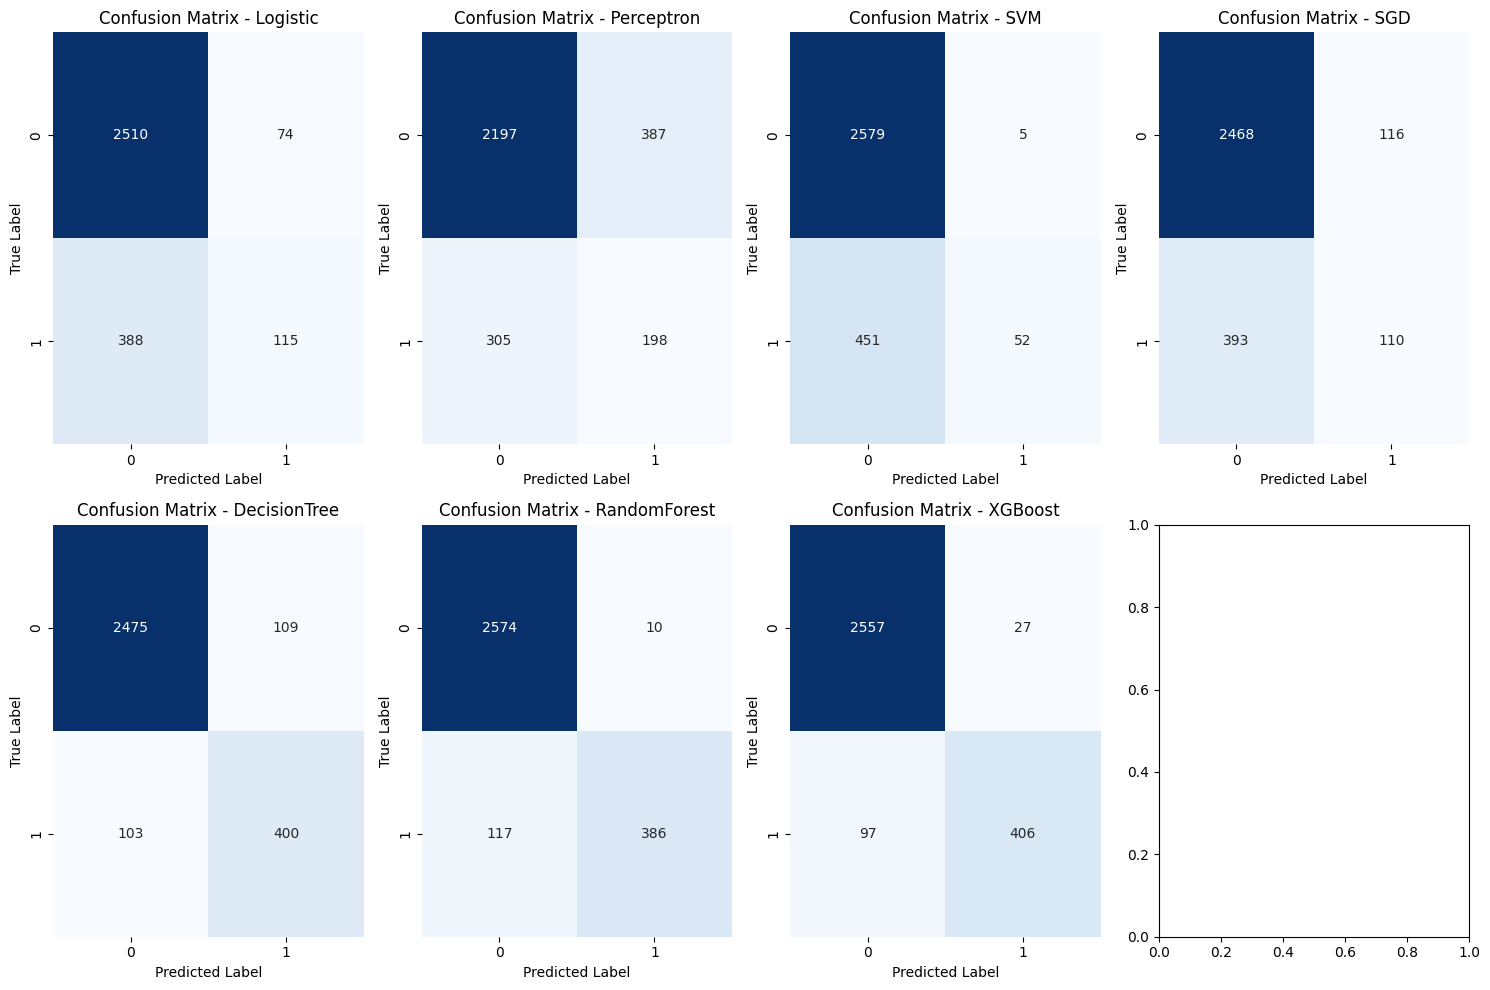

In [69]:
plot_all_confusion_matrices(conf_matrices)

## Curves

In [70]:
## precision recall curve
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(10,8))

def plot_precision_vs_recall(precisions, recalls, model_name):
    plt.plot(recalls, precisions, label=model_name, linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0,1,0,1])
    plt.legend(loc="best")
    plt.title("Precision vs recall curve")

<Figure size 1000x800 with 0 Axes>

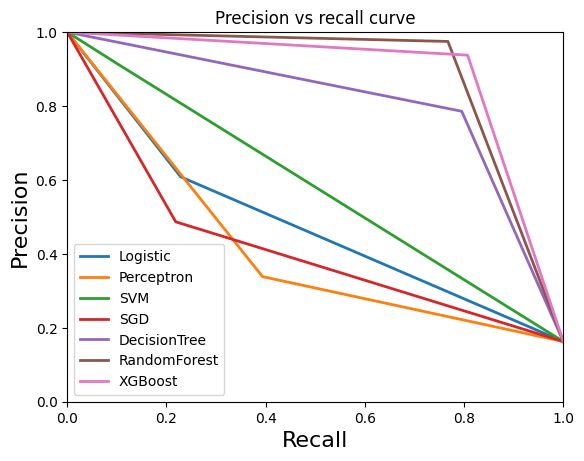

In [71]:
for model_name, (precisions,recalls, thresholds) in precision_recall.items():
    plot_precision_vs_recall(precisions, recalls, model_name)

Note: Recall falls around 0.75 value

In [72]:
# roc auc curve
def plot_roc_auc_curve(fpr, tpr, auc, model_name):
    plt.plot(fpr, tpr, label=f"{model_name}(AUC={auc:.2f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1]) 
    plt.xlabel('False Positive Rate', fontsize=16) 
    plt.ylabel('True Positive Rate', fontsize=16) 
    plt.legend(loc="best")

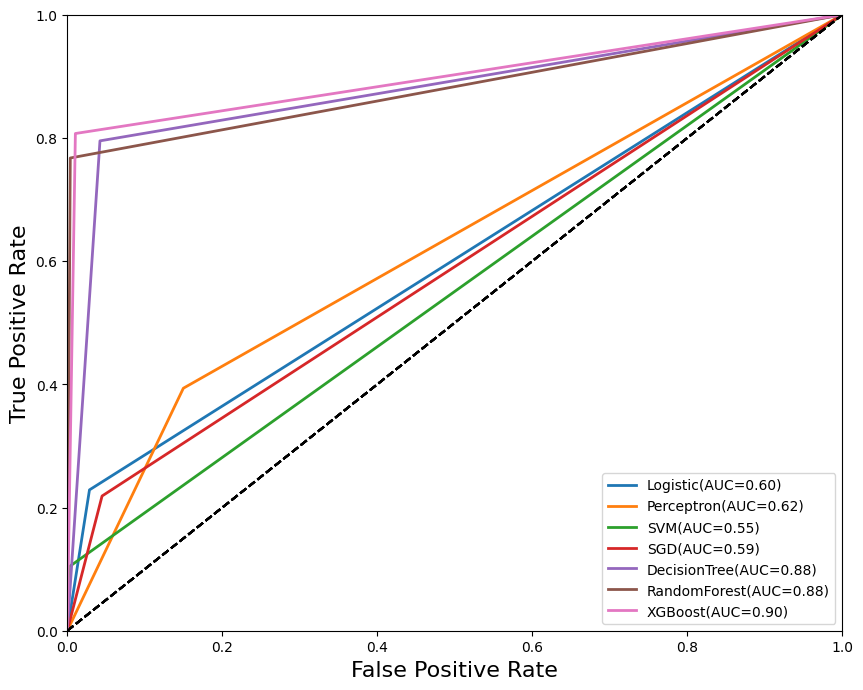

In [73]:
plt.figure(figsize=(10,8))
for model_name, (fpr, tpr, auc) in roc_data.items():
    plot_roc_auc_curve(fpr, tpr, auc, model_name)

## Results analysis

1. XGBoost stands out as the best performing model with an AUC of 0.90 and high precision and recall values (over 0.9)
2. RandomForest and DecisionTree follow closely behind with AUC of 0.88 and high precision and recall values (over 0.9)
3. Through 3-fold cross validation, XGBoost also came in first with the values [0.94752187 0.96987366 0.96209913]

In summary, __XGBoost__ was the recommended models, closely followed by __Random Forest and DecisionTrees__. The poorest in our case were SGD Classifier and SVM.

## GridSearchCV on XGBoost - [Medium Link - Optimizing XGBoost: A Guide to Hyperparameter Tuning. Medium. ](https://medium.com/@rithpansanga/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d)

In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,10],
    'learning_rate':[0.1, 0.01, 0.001, 0.2],
    'subsample':[0.5,0.7,1],
    'n_estimators':[50,100,200],
    'colsample_bytree':[0.6, 1]
}

xgb_model = XGBClassifier(random_state=42)
xgb_grid= GridSearchCV(xgb_model, param_grid, cv=3, scoring='accuracy', verbose=3)
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost Score:", xgb_grid.best_score_)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
[CV 1/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.5;, score=0.868 total time=   0.0s
[CV 2/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.5;, score=0.884 total time=   0.0s
[CV 3/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.5;, score=0.876 total time=   0.0s
[CV 1/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.7;, score=0.865 total time=   0.0s
[CV 2/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.7;, score=0.882 total time=   0.0s
[CV 3/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.7;, score=0.879 total time=   0.0s
[CV 1/3] END colsample_bytree=0.6, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1;, score=0.865 total time=   0.0s
[CV 2/3] END colsample

In [75]:
xgb_best=xgb_grid.best_estimator_
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
rf_param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[10,20,30,40],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring="accuracy")
rf_grid.fit(X_train, y_train)

print("Best RandomForest params:", rf_grid.best_params_)
print("Best RandomForest score:", rf_grid.best_score_)

Best RandomForest params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RandomForest score: 0.9591836734693877


## Randomized Search XGBoost

In [77]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

param_rand_xgboost={
    'max_depth': randint(low=1, high=10),
    'learning_rate':uniform(0.1, 0.2),
    'subsample':uniform(0.5,1),
    'n_estimators':randint(low=1, high=200),
    'colsample_bytree':uniform(0.1, 1)
}

xgb_rand = RandomizedSearchCV(xgb_model, param_rand_xgboost, n_iter=100, cv=3, scoring="accuracy", random_state=42)
xgb_rand.fit(X_train, y_train)

print("Best Parameters: ", xgb_rand.best_params_)
print("Best Score: ", xgb_rand.best_score_)

Best Parameters:  {'colsample_bytree': np.float64(0.42654076880583536), 'learning_rate': np.float64(0.2140887948810799), 'max_depth': 9, 'n_estimators': 190, 'subsample': np.float64(0.8253303307632643)}
Best Score:  0.9637188208616779


## Analyse the best models

In [78]:
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [79]:
importances_xgb= xgb_best.feature_importances_
features = X.columns
features

Index(['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement',
       'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'WorkDays', 'HoursPerDay', 'LongestAbsence',
       'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='object')

In [80]:
importances_xgb

array([0.05204277, 0.03145732, 0.02933916, 0.02710941, 0.0291568 ,
       0.04350221, 0.0287694 , 0.03229985, 0.06266745, 0.03387646,
       0.05198609, 0.04104358, 0.03928872, 0.04424798, 0.        ,
       0.04727729, 0.05011673, 0.03040875, 0.01331458, 0.05650653,
       0.0067944 , 0.02955031, 0.04090403, 0.0387965 , 0.03175928,
       0.03290241, 0.07488207], dtype=float32)

In [81]:
grouped_importances={}
for feature, importance in zip(features, importances_xgb):
    original_feature = feature.split("_")[0]
    if original_feature in grouped_importances:
        grouped_importances[original_feature] += importance
    else:
        grouped_importances[original_feature] = importance

In [82]:
sorted_importances = sorted(grouped_importances.items(), key=lambda x:x[1], reverse=True)
sorted_importances

[('MaritalStatus', np.float32(0.07488207)),
 ('TotalWorkingYears', np.float32(0.06266745)),
 ('HoursPerDay', np.float32(0.056506526)),
 ('Age', np.float32(0.052042767)),
 ('YearsAtCompany', np.float32(0.051986087)),
 ('JobSatisfaction', np.float32(0.050116725)),
 ('EnvironmentSatisfaction', np.float32(0.04727729)),
 ('JobInvolvement', np.float32(0.044247985)),
 ('NumCompaniesWorked', np.float32(0.04350221)),
 ('YearsSinceLastPromotion', np.float32(0.041043583)),
 ('Department', np.float32(0.040904034)),
 ('YearsWithCurrManager', np.float32(0.039288722)),
 ('EducationField', np.float32(0.038796496)),
 ('TrainingTimesLastYear', np.float32(0.03387646)),
 ('JobRole', np.float32(0.03290241)),
 ('StockOptionLevel', np.float32(0.03229985)),
 ('Gender', np.float32(0.03175928)),
 ('DistanceFromHome', np.float32(0.031457316)),
 ('WorkLifeBalance', np.float32(0.030408751)),
 ('BusinessTravel', np.float32(0.029550308)),
 ('Education', np.float32(0.029339164)),
 ('MonthlyIncome', np.float32(0.02915

In [83]:
sorted_df = pd.DataFrame(sorted_importances, columns=["Feature", "Importance"])

In [84]:
sorted_df

,Feature,Importance
0,MaritalStatus,0.074882
1,TotalWorkingYears,0.062667
2,HoursPerDay,0.056507
3,Age,0.052043
4,YearsAtCompany,0.051986
5,JobSatisfaction,0.050117
6,EnvironmentSatisfaction,0.047277
7,JobInvolvement,0.044248
8,NumCompaniesWorked,0.043502
9,YearsSinceLastPromotion,0.041044


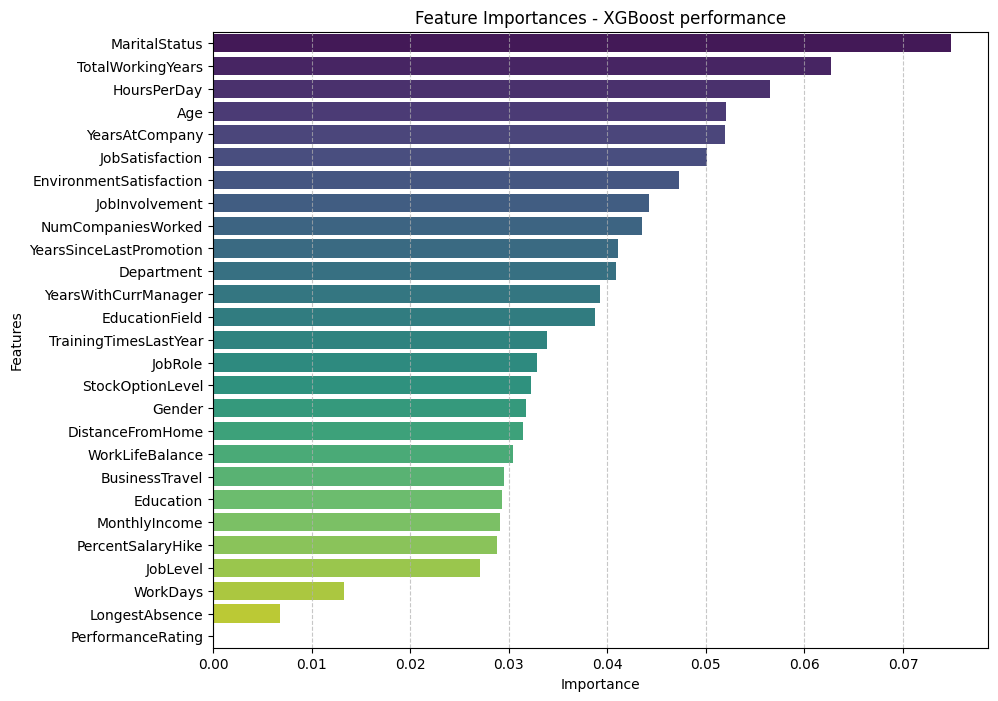

In [85]:
# plot the importances - make to df, plot df
plt.figure(figsize=(10,8))
sns.barplot(data=sorted_df.reset_index(), y="Feature", x="Importance", palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importances - XGBoost performance")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

From the feature importance, the following 7 features 'determined the greatest influence on employee turnover'.

1. TotalWorkingYears
2. MaritalStatus
3. PerformanceRating
4. HoursPerDay
5. YearsAtCompany
6. Age
7. BusinessTravel

In [86]:
import joblib
joblib.dump(xgb_model, "Project_initial_xgb.pkl")

['Project_initial_xgb.pkl']

## Testing phase

In [87]:
y_test.shape

(1323,)

In [88]:
test_scores_xgb = cross_val_score(xgb_best, X_test, y_test, cv=3, scoring="accuracy")
print(f"Cross Validation Scores on test data: {test_scores_xgb}")
y_test_pred = cross_val_predict(xgb_best, X_test, y_test, cv=3)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

print(f"Confusion matrix for XGBoost Best:", conf_matrix_test)
print(f"\nClassification report for XGBoost:\n", classification_report(y_test, y_test_pred))


Cross Validation Scores on test data: [0.9138322  0.89569161 0.91609977]
Confusion matrix for XGBoost Best: [[1090   25]
 [  96  112]]

Classification report for XGBoost:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      1115
           1       0.82      0.54      0.65       208

    accuracy                           0.91      1323
   macro avg       0.87      0.76      0.80      1323
weighted avg       0.90      0.91      0.90      1323



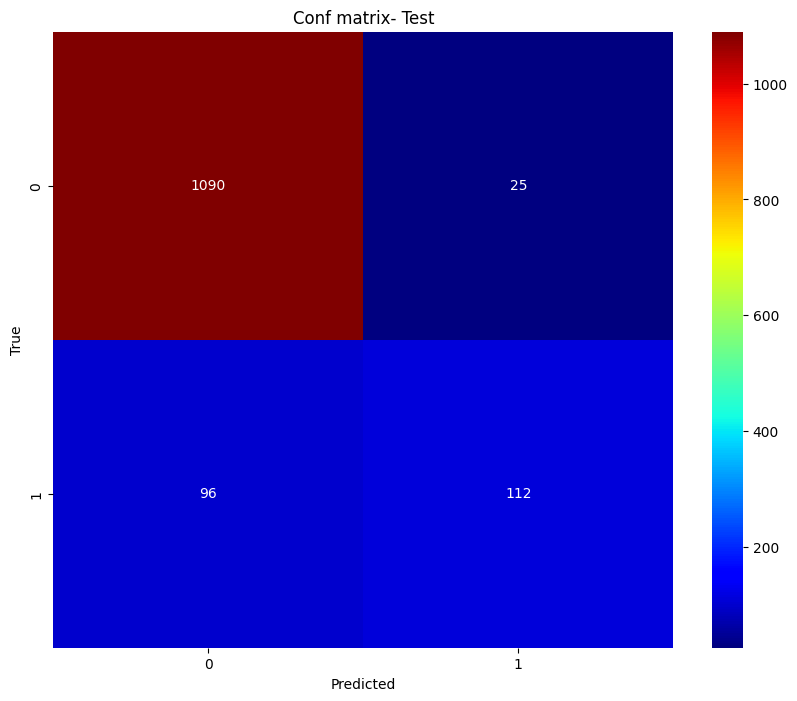

In [89]:
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="jet")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Conf matrix- Test")
plt.show()

# Ethical Aspects

What columns should we remove? **Gender, MaritalStatus, Age**

Steps to be taken:

    1. Data preparation - "all_data.csv" already prepped. Drop the columns above.
    2. Pipeline - encode and scale. 
    3. Train and test data
    4. Model selection - already selected XGBoost as the model. Perform cross val, classification report and conf matrix.
    5. Draw curves - roc/auc curve, precision vs recall, 
    6. Grid search for best parameters
    7. Feature importance
    8. Export ethical model as xgb_model_ethical.pkl

In [90]:
all_data_new = pd.read_csv("datasets/all_data.csv")

In [91]:
all_data_new

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,0,0,3,3,3.0,4.0,2.0,232,7.373651,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,1,4,2,4,3.0,2.0,4.0,236,7.718969,3
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,0,3,3,3,2.0,2.0,1.0,242,7.013240,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,7,5,2,3,4.0,4.0,3.0,235,7.193678,4
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,0,4,3,3,4.0,1.0,3.0,245,8.006175,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,No,Travel_Rarely,Research & Development,5,4,Medical,4406,Female,1,...,0,2,3,3,4.0,1.0,3.0,243,8.522277,3
4406,29,No,Travel_Rarely,Research & Development,2,4,Medical,4407,Male,1,...,0,2,2,3,4.0,4.0,3.0,241,6.092954,3
4407,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,Male,2,...,1,2,3,4,1.0,3.0,3.0,231,7.706632,3
4408,42,No,Travel_Rarely,Sales,18,2,Medical,4409,Male,1,...,7,8,2,3,4.0,1.0,3.0,241,9.492595,3


In [92]:
all_data_new.drop(['Age', 'Gender','MaritalStatus'], axis=1, inplace=True)

In [93]:
all_data_new

,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,JobLevel,JobRole,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence
0,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Healthcare Representative,131160,...,0,0,3,3,3.0,4.0,2.0,232,7.373651,3
1,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,1,Research Scientist,41890,...,1,4,2,4,3.0,2.0,4.0,236,7.718969,3
2,No,Travel_Frequently,Research & Development,17,4,Other,3,4,Sales Executive,193280,...,0,3,3,3,2.0,2.0,1.0,242,7.013240,3
3,No,Non-Travel,Research & Development,2,5,Life Sciences,4,3,Human Resources,83210,...,7,5,2,3,4.0,4.0,3.0,235,7.193678,4
4,No,Travel_Rarely,Research & Development,10,1,Medical,5,1,Sales Executive,23420,...,0,4,3,3,4.0,1.0,3.0,245,8.006175,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,No,Travel_Rarely,Research & Development,5,4,Medical,4406,1,Research Scientist,60290,...,0,2,3,3,4.0,1.0,3.0,243,8.522277,3
4406,No,Travel_Rarely,Research & Development,2,4,Medical,4407,1,Laboratory Technician,26790,...,0,2,2,3,4.0,4.0,3.0,241,6.092954,3
4407,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,2,Sales Executive,37020,...,1,2,3,4,1.0,3.0,3.0,231,7.706632,3
4408,No,Travel_Rarely,Sales,18,2,Medical,4409,1,Laboratory Technician,23980,...,7,8,2,3,4.0,1.0,3.0,241,9.492595,3


In [94]:
encoder_ethic = OrdinalEncoder()
scaler_ethic = StandardScaler()

In [95]:
categorical_features_ethic = all_data_new.select_dtypes(include=['object']).columns.drop(['Attrition'])
numerical_features_ethic = all_data_new.select_dtypes(exclude=['object']).columns.drop(['EmployeeID'])

In [96]:
categorical_features_ethic

Index(['BusinessTravel', 'Department', 'EducationField', 'JobRole'], dtype='object')

In [97]:
numerical_features_ethic

Index(['DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement',
       'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'WorkDays', 'HoursPerDay', 'LongestAbsence'],
      dtype='object')

In [98]:
all_data_new.columns

Index(['Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeID', 'JobLevel', 'JobRole',
       'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction',
       'JobSatisfaction', 'WorkLifeBalance', 'WorkDays', 'HoursPerDay',
       'LongestAbsence'],
      dtype='object')

In [99]:
full_new_pipeline = ColumnTransformer([
    ("num", num_pipeline, numerical_features_ethic),
    ("cat", encoder_ethic, categorical_features_ethic)
])

all_data_new_prepared = pd.DataFrame(full_new_pipeline.fit_transform(all_data_new))
num_feature_names_new = numerical_features_ethic
cat_feature_names_new = full_new_pipeline.named_transformers_['cat'].get_feature_names_out(categorical_features_ethic)
all_feature_names_new = list(num_feature_names_new) + list(cat_feature_names_new)
all_data_new_prepared.columns = all_feature_names_new

In [100]:
all_data_new_prepared

,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,...,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence,BusinessTravel,Department,EducationField,JobRole
0,-0.393938,-0.891688,-0.961486,1.405136,-0.678464,-1.150554,-0.932014,-1.322079,2.483396,-0.981014,...,0.252200,1.148864,-1.085336,-0.775066,-0.244123,-0.335355,2.0,2.0,1.0,0.0
1,0.099639,-1.868426,-0.961486,-0.491661,-1.079486,2.129306,0.241988,-0.678877,0.155707,-0.327893,...,0.252200,-0.666107,1.757749,-0.048210,0.013564,-0.335355,1.0,1.0,1.0,6.0
2,0.963398,1.061787,1.749610,2.725053,-0.678464,-0.057267,2.589994,-0.807517,-0.620189,-0.327893,...,-0.665460,-0.666107,-2.506879,1.042074,-0.513073,-0.335355,1.0,1.0,4.0,7.0
3,-0.887515,2.038524,0.845911,0.386301,0.123580,-1.150554,2.589994,0.221606,1.707500,0.161947,...,1.169861,1.148864,0.336206,-0.229924,-0.378424,2.553152,0.0,1.0,1.0,1.0
4,0.099639,-1.868426,-0.961486,-0.884109,0.524602,-0.877232,1.415991,-0.292956,-0.620189,-0.164613,...,1.169861,-1.573592,0.336206,1.587216,0.227886,-0.335355,2.0,1.0,3.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,-0.517332,1.061787,-0.961486,-0.100700,0.123580,0.489376,0.241988,-0.164315,1.707500,-0.654454,...,1.169861,-1.573592,0.336206,1.223788,0.613019,-0.335355,2.0,1.0,3.0,6.0
4406,-0.887515,1.061787,-0.961486,-0.812504,-0.277442,-0.057267,-0.932014,-0.164315,-0.620189,-0.654454,...,1.169861,1.148864,0.336206,0.860360,-1.199820,-0.335355,2.0,1.0,3.0,2.0
4407,1.950552,-0.891688,-0.057788,-0.595138,-1.079486,1.309341,-0.932014,-0.807517,0.931603,-0.491174,...,-1.583120,0.241379,0.336206,-0.956780,0.004358,-0.335355,2.0,1.0,1.0,7.0
4408,1.086793,-0.891688,-0.961486,-0.872210,-1.079486,-0.330589,0.241988,-0.164315,-0.620189,0.325228,...,1.169861,-1.573592,0.336206,0.860360,1.337100,-0.335355,2.0,2.0,3.0,2.0


In [101]:
print(all_data_new_prepared.shape)

(4410, 24)


In [102]:
##Train and test sets
X_new = all_data_new_prepared
y_new = all_data_new['Attrition']
X_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DistanceFromHome         4410 non-null   float64
 1   Education                4410 non-null   float64
 2   JobLevel                 4410 non-null   float64
 3   MonthlyIncome            4410 non-null   float64
 4   NumCompaniesWorked       4410 non-null   float64
 5   PercentSalaryHike        4410 non-null   float64
 6   StockOptionLevel         4410 non-null   float64
 7   TotalWorkingYears        4410 non-null   float64
 8   TrainingTimesLastYear    4410 non-null   float64
 9   YearsAtCompany           4410 non-null   float64
 10  YearsSinceLastPromotion  4410 non-null   float64
 11  YearsWithCurrManager     4410 non-null   float64
 12  JobInvolvement           4410 non-null   float64
 13  PerformanceRating        4410 non-null   float64
 14  EnvironmentSatisfaction 

In [103]:
X_new_train, X_new_test, y_new_train, y_new_test = tst(X_new, y_new, test_size=0.3, random_state=42)
print(X_new_train.shape)
print(X_new_train)

(3087, 24)
      DistanceFromHome  Education  JobLevel  MonthlyIncome  \
500          -0.517332   0.085049 -0.057788      -0.176130   
3043         -0.147150   0.085049 -0.057788      -0.300855   
2633          1.456975  -0.891688 -0.961486      -0.396046   
549          -0.393938  -0.891688 -0.961486      -0.375435   
557          -1.010909   1.061787 -0.961486      -0.827165   
...                ...        ...       ...            ...   
3444         -0.887515   0.085049 -0.057788      -0.357374   
466           2.320735   0.085049 -0.961486       1.135925   
3092          1.950552   0.085049 -0.961486      -0.870510   
3772         -1.010909   0.085049 -0.961486      -0.890058   
860          -0.640727   0.085049 -0.961486      -0.681829   

      NumCompaniesWorked  PercentSalaryHike  StockOptionLevel  \
500             0.123580          -0.877232         -0.932014   
3043            0.123580          -0.330589          0.241988   
2633           -1.079486          -1.150554      

In [104]:
y_new_train = y_new_train.replace({'Yes': 1, 'No': 0})
y_new_test = y_new_test.replace({'Yes': 1, 'No': 0})

In [105]:
##xgboost 

ethical_scores_xgb = cross_val_score(xgb_model, X_new_train, y_new_train, cv=3, scoring="accuracy")
print(f"Cross Validation Scores on test data: {ethical_scores_xgb}")

y_new_train_pred = cross_val_predict(xgb_model, X_new_train, y_new_train, cv=3)
conf_matrix_ethic = confusion_matrix(y_new_train, y_new_train_pred)

print(f"Confusion matrix for XGBoost Best:", conf_matrix_ethic)
print(f"\nClassification report for XGBoost:\n", classification_report(y_new_train, y_new_train_pred))


Cross Validation Scores on test data: [0.95918367 0.96015549 0.96112731]
Confusion matrix for XGBoost Best: [[2552   32]
 [  91  412]]

Classification report for XGBoost:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      2584
           1       0.93      0.82      0.87       503

    accuracy                           0.96      3087
   macro avg       0.95      0.90      0.92      3087
weighted avg       0.96      0.96      0.96      3087



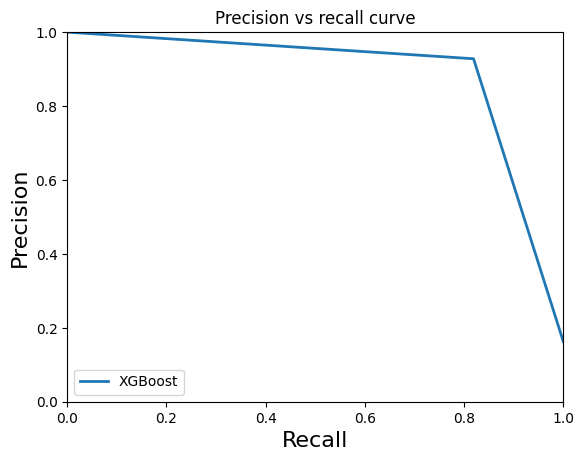

In [106]:
precisions_new, recalls_new, thresholds_new = precision_recall_curve(y_new_train, y_new_train_pred)
plot_precision_vs_recall(precisions_new, recalls_new, 'XGBoost')

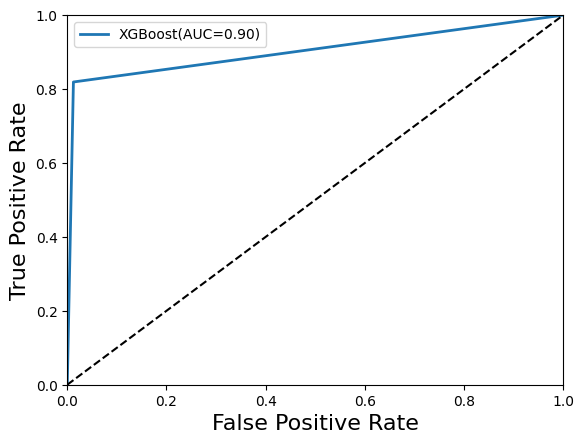

In [107]:
fpr_new, tpr_new, thresholds_new = roc_curve(y_new_train, y_new_train_pred)
auc_new=roc_auc_score(y_new_train, y_new_train_pred)
plot_roc_auc_curve(fpr_new, tpr_new, auc_new, 'XGBoost')

In [108]:
## Grid search for best parameters
param_grid = {
    'max_depth': [3,5,7,10],
    'learning_rate':[0.1, 0.01, 0.001, 0.2],
    'subsample':[0.5,0.7,1],
    'n_estimators':[50,100,200],
    'colsample_bytree':[0.6, 1]
}

xgb_model_new = XGBClassifier(random_state=42)
xgb_grid_new = GridSearchCV(xgb_model_new, param_grid, cv=3, scoring='accuracy')
xgb_grid_new.fit(X_new_train, y_new_train)

print("Best XGBoost Parameters:", xgb_grid_new.best_params_)
print("Best XGBoost Score:", xgb_grid_new.best_score_)

Best XGBoost Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}
Best XGBoost Score: 0.9620991253644315


In [109]:
xgb_ethic = xgb_grid_new.best_estimator_
xgb_ethic

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [110]:
ethic_importance = xgb_ethic.feature_importances_
features_ethic = X_new.columns
features_ethic

Index(['DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement',
       'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'WorkDays', 'HoursPerDay', 'LongestAbsence',
       'BusinessTravel', 'Department', 'EducationField', 'JobRole'],
      dtype='object')

In [111]:
ethic_importance

array([0.03453284, 0.02476359, 0.02994565, 0.0309085 , 0.0492569 ,
       0.03372331, 0.03126162, 0.07757943, 0.0466788 , 0.04609352,
       0.04326257, 0.04629529, 0.04650543, 0.04685284, 0.04691482,
       0.05176391, 0.04743292, 0.01743206, 0.05482767, 0.02532695,
       0.05030089, 0.04497664, 0.0424024 , 0.03096141], dtype=float32)

In [112]:
grouped_importances_ethic={}
for feature, importance in zip(features_ethic, ethic_importance):
    original_feature_ethic = feature.split("_")[0]
    if original_feature_ethic in grouped_importances_ethic:
        grouped_importances_ethic[original_feature_ethic] += importance
    else:
        grouped_importances_ethic[original_feature_ethic] = importance

ethic_importances = sorted(grouped_importances_ethic.items(), key=lambda x:x[1], reverse=True)
ethic_importances

[('TotalWorkingYears', np.float32(0.07757943)),
 ('HoursPerDay', np.float32(0.05482767)),
 ('JobSatisfaction', np.float32(0.051763915)),
 ('BusinessTravel', np.float32(0.050300892)),
 ('NumCompaniesWorked', np.float32(0.0492569)),
 ('WorkLifeBalance', np.float32(0.047432918)),
 ('EnvironmentSatisfaction', np.float32(0.046914816)),
 ('PerformanceRating', np.float32(0.04685284)),
 ('TrainingTimesLastYear', np.float32(0.046678796)),
 ('JobInvolvement', np.float32(0.046505433)),
 ('YearsWithCurrManager', np.float32(0.046295293)),
 ('YearsAtCompany', np.float32(0.046093516)),
 ('Department', np.float32(0.04497664)),
 ('YearsSinceLastPromotion', np.float32(0.043262567)),
 ('EducationField', np.float32(0.042402398)),
 ('DistanceFromHome', np.float32(0.034532838)),
 ('PercentSalaryHike', np.float32(0.033723313)),
 ('StockOptionLevel', np.float32(0.03126162)),
 ('JobRole', np.float32(0.030961407)),
 ('MonthlyIncome', np.float32(0.030908495)),
 ('JobLevel', np.float32(0.029945653)),
 ('LongestAb

In [113]:
ethic_df = pd.DataFrame(ethic_importances, columns=["Feature", "Importance"])
ethic_df

,Feature,Importance
0,TotalWorkingYears,0.077579
1,HoursPerDay,0.054828
2,JobSatisfaction,0.051764
3,BusinessTravel,0.050301
4,NumCompaniesWorked,0.049257
5,WorkLifeBalance,0.047433
6,EnvironmentSatisfaction,0.046915
7,PerformanceRating,0.046853
8,TrainingTimesLastYear,0.046679
9,JobInvolvement,0.046505


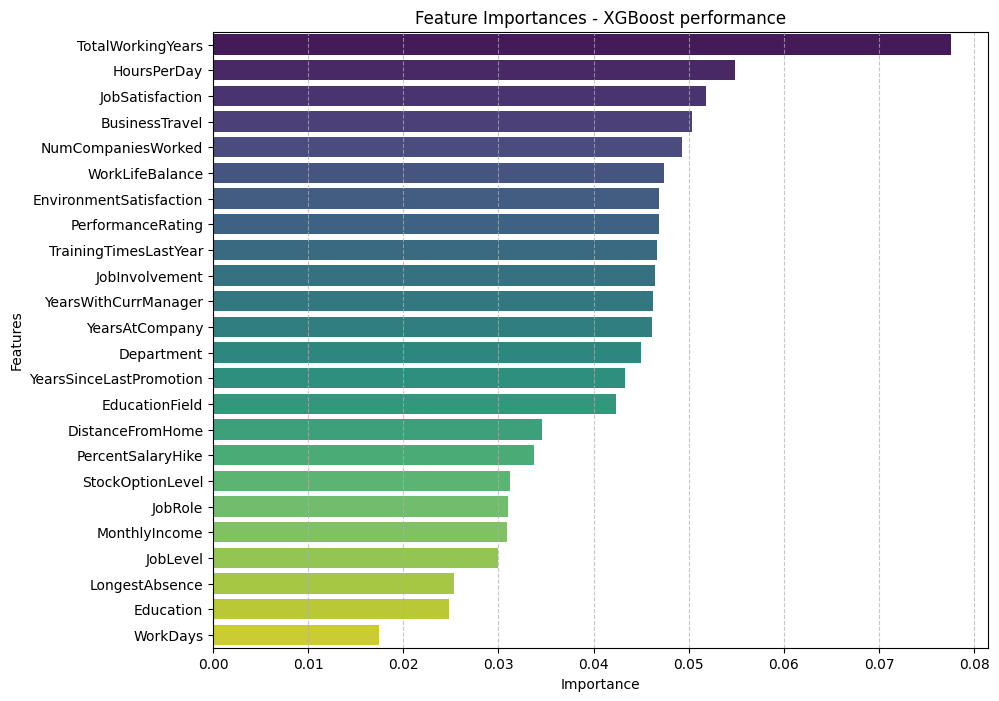

In [114]:
# plot the importances - make to df, plot df
plt.figure(figsize=(10,8))
sns.barplot(data=ethic_df.reset_index(), y="Feature", x="Importance", palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importances - XGBoost performance")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [115]:
joblib.dump(xgb_ethic, "xgb_model_ethical.pkl")

['xgb_model_ethical.pkl']

Cross Validation Scores on test data: [0.91156463 0.88435374 0.90022676]
Confusion matrix for XGBoost Best: [[1085   30]
 [ 104  104]]

Classification report for XGBoost:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      1115
           1       0.78      0.50      0.61       208

    accuracy                           0.90      1323
   macro avg       0.84      0.74      0.78      1323
weighted avg       0.89      0.90      0.89      1323



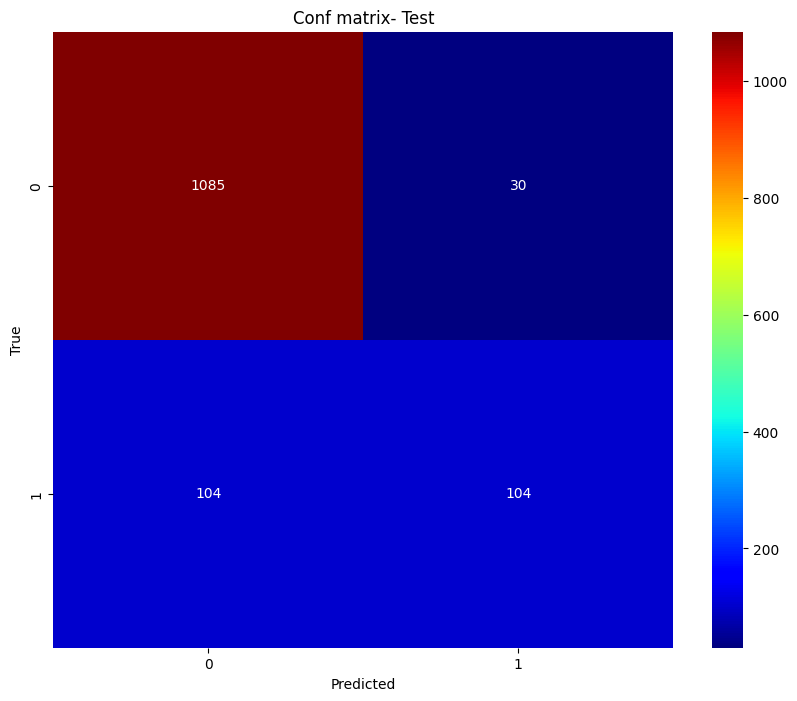

In [116]:
test_scores_ethical = cross_val_score(xgb_ethic, X_new_test, y_new_test, cv=3, scoring="accuracy")
print(f"Cross Validation Scores on test data: {test_scores_ethical}")

y_new_test_pred = cross_val_predict(xgb_ethic, X_new_test, y_new_test, cv=3)
conf_matrix_ethic = confusion_matrix(y_new_test, y_new_test_pred)

print(f"Confusion matrix for XGBoost Best:", conf_matrix_ethic)
print(f"\nClassification report for XGBoost:\n", classification_report(y_new_test, y_new_test_pred))

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_ethic, annot=True, fmt="d", cmap="jet")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Conf matrix- Test")
plt.show()

In [117]:
joblib.dump(full_new_pipeline, "ethical_pipeline.pkl")

['ethical_pipeline.pkl']

In conclusion, the best features to consider in this project are:

1. Total working years
2. Hours per days
3. Job satisfaction
4. Business travel
5. Num companies worked

Moreover, some good considerations to keep employees at the company are:

1. Give workers who stay a longer period in the company a good percent Salary Hike and ensure new employees have start benefits such as transport cards, food
2. Give flexible hours - place remote working hours.
3. Do constant job satisfaction surveys and ask for advice from employees.